In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ================================================================
# DIABETIC RETINOPATHY XAI PROJECT
# STEP 1 — CLEAN PROJECT SETUP & INPUT VERIFICATION
# ================================================================

import os
import json
import glob
import shutil
import platform
import torch
import pandas as pd

print("=" * 70)
print("STEP 1 — CLEAN PROJECT SETUP & INPUT VERIFICATION")
print("=" * 70)

# ------------------------------------------------
# 1. GPU / PYTORCH VERIFICATION
# ------------------------------------------------

print("\n[1] COMPUTING ENVIRONMENT")
print("-" * 70)

print("Python        :", platform.python_version())
print("PyTorch       :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_MEMORY_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)

    print("Device        :", DEVICE)
    print("GPU           :", GPU_NAME)
    print(f"GPU memory    : {GPU_MEMORY_GB:.2f} GB")
else:
    DEVICE = torch.device("cpu")
    GPU_NAME = "CPU"
    GPU_MEMORY_GB = 0

    print("WARNING: CUDA GPU is NOT available.")


# ------------------------------------------------
# 2. CREATE ONE PROJECT ROOT
# ------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

DIRECTORIES = [
    PROJECT_ROOT,

    # Model-specific directories
    os.path.join(PROJECT_ROOT, "models"),
    os.path.join(PROJECT_ROOT, "models", "resnet18"),
    os.path.join(PROJECT_ROOT, "models", "efficientnet_b0"),
    os.path.join(PROJECT_ROOT, "models", "densenet121"),
    os.path.join(PROJECT_ROOT, "models", "mobilenet_v3_large"),

    # Shared project directories
    os.path.join(PROJECT_ROOT, "data"),
    os.path.join(PROJECT_ROOT, "configs"),
    os.path.join(PROJECT_ROOT, "experiments"),
    os.path.join(PROJECT_ROOT, "logs"),
    os.path.join(PROJECT_ROOT, "backups"),
]

for directory in DIRECTORIES:
    os.makedirs(directory, exist_ok=True)

print("\n[2] PROJECT STRUCTURE")
print("-" * 70)
print("Project root:", PROJECT_ROOT)

# ------------------------------------------------
# 3. FIND APTOS DATASET
# ------------------------------------------------

print("\n[3] SEARCHING FOR APTOS DATASET")
print("-" * 70)

aptos_train_candidates = []

for root, dirs, files in os.walk("/kaggle/input"):
    if "train.csv" in files:
        candidate = os.path.join(root, "train.csv")

        # Prefer paths belonging to APTOS
        if "aptos" in candidate.lower() or "blindness" in candidate.lower():
            aptos_train_candidates.append(candidate)

if len(aptos_train_candidates) == 0:
    raise FileNotFoundError(
        "APTOS train.csv was not found under /kaggle/input"
    )

APTOS_CSV = aptos_train_candidates[0]
APTOS_ROOT = os.path.dirname(APTOS_CSV)
APTOS_IMAGE_DIR = os.path.join(APTOS_ROOT, "train_images")

print("APTOS CSV     :", APTOS_CSV)
print("Image folder  :", APTOS_IMAGE_DIR)

if not os.path.exists(APTOS_CSV):
    raise FileNotFoundError("APTOS train.csv does not exist.")

if not os.path.isdir(APTOS_IMAGE_DIR):
    raise FileNotFoundError("APTOS train_images directory does not exist.")


# ------------------------------------------------
# 4. VERIFY APTOS CSV
# ------------------------------------------------

print("\n[4] VERIFYING APTOS CSV")
print("-" * 70)

aptos_df = pd.read_csv(APTOS_CSV)

print("Rows          :", len(aptos_df))
print("Columns       :", list(aptos_df.columns))

required_aptos_columns = {"id_code", "diagnosis"}

if not required_aptos_columns.issubset(aptos_df.columns):
    raise ValueError(
        f"APTOS CSV must contain {required_aptos_columns}, "
        f"but found {set(aptos_df.columns)}"
    )

print("\nClass distribution:")
print(aptos_df["diagnosis"].value_counts().sort_index())


# ------------------------------------------------
# 5. FIND FIXED SPLIT FILES
# ------------------------------------------------

print("\n[5] SEARCHING FOR FIXED SPLITS")
print("-" * 70)

split_files = {}

for root, dirs, files in os.walk("/kaggle/input"):

    for filename in [
        "train_split.csv",
        "val_split.csv",
        "test_split.csv"
    ]:
        if filename in files and filename not in split_files:
            split_files[filename] = os.path.join(root, filename)

for filename in [
    "train_split.csv",
    "val_split.csv",
    "test_split.csv"
]:
    if filename in split_files:
        print(f"{filename:<18}: FOUND")
        print(" " * 18, split_files[filename])
    else:
        print(f"{filename:<18}: MISSING")


missing_splits = [
    filename
    for filename in [
        "train_split.csv",
        "val_split.csv",
        "test_split.csv"
    ]
    if filename not in split_files
]

if missing_splits:
    raise FileNotFoundError(
        "Missing fixed split files: " + ", ".join(missing_splits)
    )


TRAIN_SPLIT = split_files["train_split.csv"]
VAL_SPLIT = split_files["val_split.csv"]
TEST_SPLIT = split_files["test_split.csv"]


# ------------------------------------------------
# 6. LOAD SPLITS
# ------------------------------------------------

print("\n[6] LOADING FIXED SPLITS")
print("-" * 70)

train_df = pd.read_csv(TRAIN_SPLIT)
val_df = pd.read_csv(VAL_SPLIT)
test_df = pd.read_csv(TEST_SPLIT)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))


# ------------------------------------------------
# 7. SAVE PROJECT CONFIGURATION
# ------------------------------------------------

CONFIG = {
    "project_name": "Explainable AI for Diabetic Retinopathy Screening",

    "dataset": {
        "name": "APTOS 2019 Blindness Detection",
        "csv": APTOS_CSV,
        "image_directory": APTOS_IMAGE_DIR,
        "total_images": int(len(aptos_df))
    },

    "splits": {
        "train_csv": TRAIN_SPLIT,
        "validation_csv": VAL_SPLIT,
        "test_csv": TEST_SPLIT,
        "train_size": int(len(train_df)),
        "validation_size": int(len(val_df)),
        "test_size": int(len(test_df))
    },

    "image": {
        "size": 224,
        "channels": 3
    },

    "training": {
        "batch_size": 16,
        "learning_rate": 0.0001,
        "weight_decay": 0.0001,
        "max_epochs": 20,
        "early_stopping_patience": 5,
        "num_classes": 5
    },

    "device": {
        "device": str(DEVICE),
        "gpu": GPU_NAME,
        "gpu_memory_gb": round(GPU_MEMORY_GB, 2)
    }
}

CONFIG_PATH = os.path.join(
    PROJECT_ROOT,
    "configs",
    "project_config.json"
)

with open(CONFIG_PATH, "w") as f:
    json.dump(CONFIG, f, indent=4)

print("\n[7] CONFIGURATION SAVED")
print("Config:", CONFIG_PATH)


# ------------------------------------------------
# 8. FINAL CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 1 COMPLETE")
print("=" * 70)

print("✓ PyTorch environment verified")
print("✓ GPU environment checked")
print("✓ Project directory created")
print("✓ APTOS dataset located")
print("✓ APTOS CSV verified")
print("✓ Fixed train/validation/test splits located")
print("✓ Split sizes recorded")
print("✓ Configuration saved")

print("\nProject root:")
print(PROJECT_ROOT)

print("\nREADY FOR STEP 2 — DATASET & SPLIT INTEGRITY VERIFICATION")
print("=" * 70)

STEP 1 — CLEAN PROJECT SETUP & INPUT VERIFICATION

[1] COMPUTING ENVIRONMENT
----------------------------------------------------------------------
Python        : 3.12.13
PyTorch       : 2.10.0+cu128
CUDA available: True
Device        : cuda:0
GPU           : Tesla T4
GPU memory    : 14.56 GB

[2] PROJECT STRUCTURE
----------------------------------------------------------------------
Project root: /kaggle/working/DR_XAI_Project

[3] SEARCHING FOR APTOS DATASET
----------------------------------------------------------------------
APTOS CSV     : /kaggle/input/competitions/aptos2019-blindness-detection/train.csv
Image folder  : /kaggle/input/competitions/aptos2019-blindness-detection/train_images

[4] VERIFYING APTOS CSV
----------------------------------------------------------------------
Rows          : 3662
Columns       : ['id_code', 'diagnosis']

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

[5] SEARCHING FOR FIXED SPL

In [2]:
# ================================================================
# STEP 2 — DATASET & FIXED SPLIT INTEGRITY VERIFICATION
# ================================================================

import os
import pandas as pd

print("=" * 70)
print("STEP 2 — DATASET & FIXED SPLIT INTEGRITY VERIFICATION")
print("=" * 70)

# ------------------------------------------------
# 1. REQUIRED COLUMNS
# ------------------------------------------------

print("\n[1] CHECKING REQUIRED COLUMNS")
print("-" * 70)

required_columns = {"id_code", "diagnosis"}

for name, df in [
    ("APTOS", aptos_df),
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:
    missing = required_columns - set(df.columns)

    print(f"{name:<12}:", "PASSED" if not missing else f"MISSING {missing}")

    if missing:
        raise ValueError(
            f"{name} is missing columns: {missing}"
        )


# ------------------------------------------------
# 2. DUPLICATE ID CHECK
# ------------------------------------------------

print("\n[2] CHECKING DUPLICATE IMAGE IDs")
print("-" * 70)

for name, df in [
    ("APTOS", aptos_df),
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:
    duplicates = df["id_code"].duplicated().sum()

    print(f"{name:<12}: {duplicates} duplicates")

    if duplicates != 0:
        raise ValueError(
            f"Duplicate image IDs found in {name}"
        )


# ------------------------------------------------
# 3. SPLIT OVERLAP CHECK
# ------------------------------------------------

print("\n[3] CHECKING TRAIN / VALIDATION / TEST OVERLAP")
print("-" * 70)

train_ids = set(train_df["id_code"])
val_ids = set(val_df["id_code"])
test_ids = set(test_df["id_code"])

train_val_overlap = train_ids & val_ids
train_test_overlap = train_ids & test_ids
val_test_overlap = val_ids & test_ids

print("Train ↔ Validation :", len(train_val_overlap))
print("Train ↔ Test       :", len(train_test_overlap))
print("Validation ↔ Test  :", len(val_test_overlap))

if train_val_overlap or train_test_overlap or val_test_overlap:
    raise ValueError("DATA LEAKAGE DETECTED — split overlap exists.")

print("\nNo overlap: PASSED")


# ------------------------------------------------
# 4. SPLIT SIZE CHECK
# ------------------------------------------------

print("\n[4] CHECKING SPLIT SIZES")
print("-" * 70)

expected_train = 2563
expected_val = 549
expected_test = 550

print("Train      :", len(train_df), "| Expected:", expected_train)
print("Validation :", len(val_df), "| Expected:", expected_val)
print("Test       :", len(test_df), "| Expected:", expected_test)

if (
    len(train_df) != expected_train
    or len(val_df) != expected_val
    or len(test_df) != expected_test
):
    raise ValueError("Split sizes do not match the fixed experimental split.")

print("\nSplit sizes: PASSED")


# ------------------------------------------------
# 5. TOTAL UNIQUE IMAGES
# ------------------------------------------------

print("\n[5] CHECKING TOTAL UNIQUE IMAGES")
print("-" * 70)

all_split_ids = train_ids | val_ids | test_ids

print("Unique split IDs :", len(all_split_ids))
print("APTOS rows       :", len(aptos_df))

if len(all_split_ids) != len(aptos_df):
    raise ValueError(
        "The splits do not contain exactly all APTOS images."
    )

print("Total image coverage: PASSED")


# ------------------------------------------------
# 6. IMAGE FILE AVAILABILITY
# ------------------------------------------------

print("\n[6] CHECKING IMAGE FILE AVAILABILITY")
print("-" * 70)

missing_images = []

for image_id in all_split_ids:

    image_path = os.path.join(
        APTOS_IMAGE_DIR,
        f"{image_id}.png"
    )

    if not os.path.exists(image_path):
        missing_images.append(image_id)

print("Images expected :", len(all_split_ids))
print("Missing images  :", len(missing_images))

if missing_images:
    print("\nFirst missing images:")
    print(missing_images[:10])

    raise FileNotFoundError(
        f"{len(missing_images)} split images are missing."
    )

print("All split images available: PASSED")


# ------------------------------------------------
# 7. LABEL CONSISTENCY CHECK
# ------------------------------------------------

print("\n[7] CHECKING LABEL CONSISTENCY")
print("-" * 70)

aptos_labels = (
    aptos_df
    .set_index("id_code")["diagnosis"]
)

for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    mismatches = 0

    for _, row in df.iterrows():

        image_id = row["id_code"]
        split_label = row["diagnosis"]

        if image_id not in aptos_labels.index:
            raise ValueError(
                f"{image_id} from {name} is not present in APTOS."
            )

        original_label = aptos_labels.loc[image_id]

        if int(split_label) != int(original_label):
            mismatches += 1

    print(f"{name:<12}: {mismatches} label mismatches")

    if mismatches != 0:
        raise ValueError(
            f"Label mismatch detected in {name}."
        )


print("\nLabel consistency: PASSED")


# ------------------------------------------------
# 8. CLASS DISTRIBUTION
# ------------------------------------------------

print("\n[8] CLASS DISTRIBUTION")
print("-" * 70)

print("\nTRAIN")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nTEST")
print(test_df["diagnosis"].value_counts().sort_index())


# ------------------------------------------------
# 9. FINAL INTEGRITY SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 2 COMPLETE")
print("=" * 70)

print("✓ Required columns verified")
print("✓ Duplicate IDs checked")
print("✓ Train/validation/test overlap checked")
print("✓ Fixed split sizes verified")
print("✓ All 3662 images accounted for")
print("✓ All image files available")
print("✓ Labels verified against APTOS")
print("✓ Class distributions recorded")

print("\nDATA INTEGRITY: PASSED")
print("READY FOR STEP 3 — PREPROCESSING & DATALOADERS")
print("=" * 70)

STEP 2 — DATASET & FIXED SPLIT INTEGRITY VERIFICATION

[1] CHECKING REQUIRED COLUMNS
----------------------------------------------------------------------
APTOS       : PASSED
TRAIN       : PASSED
VALIDATION  : PASSED
TEST        : PASSED

[2] CHECKING DUPLICATE IMAGE IDs
----------------------------------------------------------------------
APTOS       : 0 duplicates
TRAIN       : 0 duplicates
VALIDATION  : 0 duplicates
TEST        : 0 duplicates

[3] CHECKING TRAIN / VALIDATION / TEST OVERLAP
----------------------------------------------------------------------
Train ↔ Validation : 0
Train ↔ Test       : 0
Validation ↔ Test  : 0

No overlap: PASSED

[4] CHECKING SPLIT SIZES
----------------------------------------------------------------------
Train      : 2563 | Expected: 2563
Validation : 549 | Expected: 549
Test       : 550 | Expected: 550

Split sizes: PASSED

[5] CHECKING TOTAL UNIQUE IMAGES
----------------------------------------------------------------------
Unique split ID

In [3]:
# ============================================================
# STEP 3 — PREPROCESSING & DATALOADERS
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("=" * 70)
print("STEP 3 — PREPROCESSING & DATALOADERS")
print("=" * 70)

# ------------------------------------------------------------
# 1. REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\n[1] REPRODUCIBILITY")
print("-" * 70)
print("Random seed:", SEED)

# ------------------------------------------------------------
# 2. PATHS
# ------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

APTOS_ROOT = "/kaggle/input/competitions/aptos2019-blindness-detection"
IMAGE_DIR = os.path.join(APTOS_ROOT, "train_images")

SPLIT_ROOT = "/kaggle/input/datasets/dharshini2362005/finalaptos"

TRAIN_CSV = os.path.join(SPLIT_ROOT, "train_split.csv")
VAL_CSV   = os.path.join(SPLIT_ROOT, "val_split.csv")
TEST_CSV  = os.path.join(SPLIT_ROOT, "test_split.csv")

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
CONFIG_DIR = os.path.join(PROJECT_ROOT, "configs")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

print("\n[2] PATHS")
print("-" * 70)
print("Project root :", PROJECT_ROOT)
print("Image folder :", IMAGE_DIR)
print("Split folder :", SPLIT_ROOT)

# ------------------------------------------------------------
# 3. LOAD FIXED SPLITS
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("\n[3] DATASET SIZES")
print("-" * 70)
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

# ------------------------------------------------------------
# 4. DATASET CLASS
# ------------------------------------------------------------

class APTOSDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_id = str(row["id_code"])
        label = int(row["diagnosis"])

        image_path = os.path.join(
            self.image_dir,
            image_id + ".png"
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# ------------------------------------------------------------
# 5. IMAGE TRANSFORMS
# ------------------------------------------------------------

IMAGE_SIZE = 224

# Training:
# Moderate augmentation only.
# NO ColorJitter.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test:
# NO random augmentation.
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\n[4] PREPROCESSING")
print("-" * 70)
print("Image size        :", IMAGE_SIZE)
print("Training resize   : 224 x 224")
print("Training augment  : Horizontal Flip")
print("ColorJitter       : NOT USED")
print("Normalization     : ImageNet")
print("Validation random : NO")
print("Test random       : NO")

# ------------------------------------------------------------
# 6. CREATE DATASETS
# ------------------------------------------------------------

train_dataset = APTOSDataset(
    train_df,
    IMAGE_DIR,
    train_transform
)

val_dataset = APTOSDataset(
    val_df,
    IMAGE_DIR,
    eval_transform
)

test_dataset = APTOSDataset(
    test_df,
    IMAGE_DIR,
    eval_transform
)

print("\n[5] DATASETS CREATED")
print("-" * 70)
print("Train dataset      :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Test dataset       :", len(test_dataset))

# ------------------------------------------------------------
# 7. DATALOADERS
# ------------------------------------------------------------

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\n[6] DATALOADERS")
print("-" * 70)
print("Batch size       :", BATCH_SIZE)
print("Workers          :", NUM_WORKERS)
print("Train batches    :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches     :", len(test_loader))

# ------------------------------------------------------------
# 8. BATCH VERIFICATION
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\n[7] TRAIN BATCH VERIFICATION")
print("-" * 70)
print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Image dtype :", images.dtype)
print("Label dtype :", labels.dtype)
print("Image min   :", images.min().item())
print("Image max   :", images.max().item())
print("Labels      :", labels.tolist())

# Validation batch
val_images, val_labels = next(iter(val_loader))

print("\n[8] VALIDATION BATCH")
print("-" * 70)
print("Image shape :", val_images.shape)
print("Label shape :", val_labels.shape)

# Test batch
test_images, test_labels = next(iter(test_loader))

print("\n[9] TEST BATCH")
print("-" * 70)
print("Image shape :", test_images.shape)
print("Label shape :", test_labels.shape)

# ------------------------------------------------------------
# 9. SAVE PREPROCESSING CONFIGURATION
# ------------------------------------------------------------

preprocessing_config = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "seed": SEED,
    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    },
    "train_augmentation": [
        "Resize(224,224)",
        "RandomHorizontalFlip(p=0.5)",
        "ToTensor",
        "ImageNetNormalization"
    ],
    "validation_preprocessing": [
        "Resize(224,224)",
        "ToTensor",
        "ImageNetNormalization"
    ],
    "test_preprocessing": [
        "Resize(224,224)",
        "ToTensor",
        "ImageNetNormalization"
    ],
    "color_jitter": False,
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "test_samples": len(test_dataset)
}

config_path = os.path.join(
    CONFIG_DIR,
    "preprocessing_config.json"
)

with open(config_path, "w") as f:
    json.dump(preprocessing_config, f, indent=4)

print("\n[10] CONFIGURATION SAVED")
print("-" * 70)
print("Saved:", config_path)

# ------------------------------------------------------------
# 10. FINAL VERIFICATION
# ------------------------------------------------------------

assert images.shape == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
assert labels.shape == (BATCH_SIZE,)
assert images.dtype == torch.float32
assert labels.dtype == torch.int64

assert len(train_dataset) == 2563
assert len(val_dataset) == 549
assert len(test_dataset) == 550

print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

print("✓ Fixed train dataset created")
print("✓ Fixed validation dataset created")
print("✓ Fixed test dataset created")
print("✓ Training preprocessing verified")
print("✓ Validation preprocessing verified")
print("✓ Test preprocessing verified")
print("✓ No ColorJitter")
print("✓ ImageNet normalization verified")
print("✓ Train DataLoader created")
print("✓ Validation DataLoader created")
print("✓ Test DataLoader created")
print("✓ Batch dimensions verified")
print("✓ Preprocessing configuration saved")

print("\nREADY FOR STEP 4 — MODEL DEFINITIONS")
print("=" * 70)

STEP 3 — PREPROCESSING & DATALOADERS

[1] REPRODUCIBILITY
----------------------------------------------------------------------
Random seed: 42

[2] PATHS
----------------------------------------------------------------------
Project root : /kaggle/working/DR_XAI_Project
Image folder : /kaggle/input/competitions/aptos2019-blindness-detection/train_images
Split folder : /kaggle/input/datasets/dharshini2362005/finalaptos

[3] DATASET SIZES
----------------------------------------------------------------------
Train      : 2563
Validation : 549
Test       : 550

[4] PREPROCESSING
----------------------------------------------------------------------
Image size        : 224
Training resize   : 224 x 224
Training augment  : Horizontal Flip
ColorJitter       : NOT USED
Normalization     : ImageNet
Validation random : NO
Test random       : NO

[5] DATASETS CREATED
----------------------------------------------------------------------
Train dataset      : 2563
Validation dataset : 549
Test d

In [4]:
# ================================================================
# STEP 4 — CNN MODEL DEFINITIONS
# ================================================================

import os
import json
import torch
import torch.nn as nn

from torchvision import models

print("=" * 70)
print("STEP 4 — CNN MODEL DEFINITIONS")
print("=" * 70)

# ------------------------------------------------
# 1. DEVICE
# ------------------------------------------------

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("\n[1] DEVICE")
print("-" * 70)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

# ------------------------------------------------
# 2. NUMBER OF CLASSES
# ------------------------------------------------

NUM_CLASSES = 5

CLASS_NAMES = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative_DR"
}

print("\n[2] CLASS CONFIGURATION")
print("-" * 70)

for index, name in CLASS_NAMES.items():
    print(f"{index} -> {name}")

# ------------------------------------------------
# 3. MODEL CREATION FUNCTIONS
# ------------------------------------------------

def create_resnet18():
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        NUM_CLASSES
    )

    return model


def create_efficientnet_b0():
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES
    )

    return model


def create_densenet121():
    model = models.densenet121(
        weights=models.DenseNet121_Weights.DEFAULT
    )

    model.classifier = nn.Linear(
        model.classifier.in_features,
        NUM_CLASSES
    )

    return model


def create_mobilenet_v3_large():
    model = models.mobilenet_v3_large(
        weights=models.MobileNet_V3_Large_Weights.DEFAULT
    )

    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        NUM_CLASSES
    )

    return model


# ------------------------------------------------
# 4. CREATE MODELS
# ------------------------------------------------

print("\n[3] CREATING MODELS")
print("-" * 70)

models_dict = {
    "resnet18": create_resnet18(),
    "efficientnet_b0": create_efficientnet_b0(),
    "densenet121": create_densenet121(),
    "mobilenet_v3_large": create_mobilenet_v3_large()
}

# ------------------------------------------------
# 5. MODEL INFORMATION
# ------------------------------------------------

print("\n[4] MODEL INFORMATION")
print("-" * 70)

model_information = {}

for name, model in models_dict.items():

    total_params = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_params = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print("\n" + "-" * 60)
    print("Model:", name)
    print("Total parameters     :", f"{total_params:,}")
    print("Trainable parameters :", f"{trainable_params:,}")

    model_information[name] = {
        "total_parameters": int(total_params),
        "trainable_parameters": int(trainable_params)
    }

# ------------------------------------------------
# 6. OUTPUT LAYER VERIFICATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("OUTPUT LAYER VERIFICATION")
print("=" * 70)

# ResNet18
print(
    "ResNet18            ->",
    models_dict["resnet18"].fc
)

# EfficientNet
print(
    "EfficientNet-B0     ->",
    models_dict["efficientnet_b0"].classifier[1]
)

# DenseNet
print(
    "DenseNet121         ->",
    models_dict["densenet121"].classifier
)

# MobileNet
print(
    "MobileNetV3-Large   ->",
    models_dict["mobilenet_v3_large"].classifier[3]
)

# ------------------------------------------------
# 7. FORWARD PASS VERIFICATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("FORWARD PASS VERIFICATION")
print("=" * 70)

# Use CPU for this verification so we don't unnecessarily
# occupy GPU memory before actual training.

test_input = torch.randn(
    2,
    3,
    224,
    224
)

for name, model in models_dict.items():

    model_cpu = model.cpu()
    model_cpu.eval()

    with torch.no_grad():
        output = model_cpu(test_input)

    print(
        f"{name:<22} -> "
        f"input {tuple(test_input.shape)} "
        f"output {tuple(output.shape)}"
    )

    assert output.shape == (2, NUM_CLASSES)

# ------------------------------------------------
# 8. GPU MEMORY CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("GPU MEMORY STATUS")
print("=" * 70)

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    allocated = (
        torch.cuda.memory_allocated(0)
        / (1024 ** 3)
    )

    reserved = (
        torch.cuda.memory_reserved(0)
        / (1024 ** 3)
    )

    print(f"GPU allocated : {allocated:.3f} GB")
    print(f"GPU reserved  : {reserved:.3f} GB")

else:

    print("CUDA not available.")

# ------------------------------------------------
# 9. SAVE MODEL CONFIGURATION
# ------------------------------------------------

CONFIG_DIR = os.path.join(
    PROJECT_ROOT,
    "configs"
)

os.makedirs(CONFIG_DIR, exist_ok=True)

model_config = {
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "pretrained": True,
    "architectures": model_information
}

MODEL_CONFIG_PATH = os.path.join(
    CONFIG_DIR,
    "model_config.json"
)

with open(MODEL_CONFIG_PATH, "w") as f:
    json.dump(model_config, f, indent=4)

print("\n[5] MODEL CONFIGURATION SAVED")
print("-" * 70)
print("Saved:", MODEL_CONFIG_PATH)

# ------------------------------------------------
# 10. DELETE TEMPORARY MODELS
# ------------------------------------------------

# We do not need four copies occupying memory.
# Actual training will create the selected model separately.

del models_dict

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------
# FINAL
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 4 COMPLETE")
print("=" * 70)

print("✓ ResNet18 created")
print("✓ EfficientNet-B0 created")
print("✓ DenseNet121 created")
print("✓ MobileNetV3-Large created")
print("✓ ImageNet pretrained weights loaded")
print("✓ Five-class output layers verified")
print("✓ Forward passes verified")
print("✓ Model parameter counts recorded")
print("✓ Model configuration saved")
print("✓ Temporary model memory released")

print("\nREADY FOR STEP 5 — PROTECTED TRAINING & EVALUATION ENGINE")
print("=" * 70)

STEP 4 — CNN MODEL DEFINITIONS

[1] DEVICE
----------------------------------------------------------------------
Device: cuda:0
GPU   : Tesla T4

[2] CLASS CONFIGURATION
----------------------------------------------------------------------
0 -> No_DR
1 -> Mild
2 -> Moderate
3 -> Severe
4 -> Proliferative_DR

[3] CREATING MODELS
----------------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 172MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 83.1MB/s]



[4] MODEL INFORMATION
----------------------------------------------------------------------

------------------------------------------------------------
Model: resnet18
Total parameters     : 11,179,077
Trainable parameters : 11,179,077

------------------------------------------------------------
Model: efficientnet_b0
Total parameters     : 4,013,953
Trainable parameters : 4,013,953

------------------------------------------------------------
Model: densenet121
Total parameters     : 6,958,981
Trainable parameters : 6,958,981

------------------------------------------------------------
Model: mobilenet_v3_large
Total parameters     : 4,208,437
Trainable parameters : 4,208,437

OUTPUT LAYER VERIFICATION
ResNet18            -> Linear(in_features=512, out_features=5, bias=True)
EfficientNet-B0     -> Linear(in_features=1280, out_features=5, bias=True)
DenseNet121         -> Linear(in_features=1024, out_features=5, bias=True)
MobileNetV3-Large   -> Linear(in_features=1280, out_featu

In [5]:
# ================================================================
# STEP 5 — PROTECTED TRAINING & EVALUATION ENGINE
# ================================================================

import os
import json
import csv
import shutil
import tempfile
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

print("=" * 70)
print("STEP 5 — PROTECTED TRAINING & EVALUATION ENGINE")
print("=" * 70)

# ------------------------------------------------
# 1. DEVICE
# ------------------------------------------------

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("\n[1] DEVICE")
print("-" * 70)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------
# 2. PROJECT DIRECTORIES
# ------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_ROOT = os.path.join(
    PROJECT_ROOT,
    "checkpoints"
)

RESULTS_ROOT = os.path.join(
    PROJECT_ROOT,
    "results"
)

LOG_ROOT = os.path.join(
    PROJECT_ROOT,
    "logs"
)

for directory in [
    CHECKPOINT_ROOT,
    RESULTS_ROOT,
    LOG_ROOT
]:
    os.makedirs(directory, exist_ok=True)

print("\n[2] PROJECT DIRECTORIES")
print("-" * 70)
print("Checkpoint root:", CHECKPOINT_ROOT)
print("Results root   :", RESULTS_ROOT)
print("Log root       :", LOG_ROOT)


# ------------------------------------------------
# 3. TRAINING CONFIGURATION
# ------------------------------------------------

NUM_CLASSES = 5

LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

# These are the class weights already established
# for the fixed APTOS training split.
CLASS_WEIGHTS = torch.tensor(
    [0.216, 1.054, 0.390, 2.021, 1.318],
    dtype=torch.float32
)

print("\n[3] TRAINING CONFIGURATION")
print("-" * 70)
print("Learning rate       :", LEARNING_RATE)
print("Weight decay        :", WEIGHT_DECAY)
print("Maximum epochs      :", MAX_EPOCHS)
print("Early stopping      :", EARLY_STOPPING_PATIENCE)
print("Class weights       :", CLASS_WEIGHTS.tolist())


# ------------------------------------------------
# 4. CLASS-WEIGHTED LOSS
# ------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS.to(DEVICE)
)

print("\n[4] LOSS FUNCTION")
print("-" * 70)
print("Loss: Class-weighted CrossEntropyLoss")
print("Loss device:", DEVICE)


# ------------------------------------------------
# 5. METRIC FUNCTION
# ------------------------------------------------

def calculate_metrics(y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    qwk = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "qwk": float(qwk)
    }


# ------------------------------------------------
# 6. TRAINING FUNCTION
# ------------------------------------------------

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions
    )

    return epoch_loss, metrics


# ------------------------------------------------
# 7. VALIDATION FUNCTION
# ------------------------------------------------

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_labels.extend(
                labels.detach().cpu().numpy()
            )

            all_predictions.extend(
                predictions.detach().cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions
    )

    return epoch_loss, metrics


# ------------------------------------------------
# 8. ATOMIC CHECKPOINT SAVING
# ------------------------------------------------

def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch,
    best_qwk,
    patience_counter,
    history
):

    os.makedirs(
        os.path.dirname(path),
        exist_ok=True
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": (
            scheduler.state_dict()
            if scheduler is not None
            else None
        ),
        "best_qwk": best_qwk,
        "patience_counter": patience_counter,
        "history": history
    }

    # Write to temporary file first.
    # Only replace the real checkpoint after
    # the temporary file has been successfully written.

    directory = os.path.dirname(path)

    fd, temp_path = tempfile.mkstemp(
        suffix=".tmp",
        dir=directory
    )

    os.close(fd)

    try:

        torch.save(
            checkpoint,
            temp_path
        )

        # Verify temporary checkpoint exists
        if not os.path.exists(temp_path):
            raise RuntimeError(
                "Temporary checkpoint was not created."
            )

        # Replace target atomically
        os.replace(
            temp_path,
            path
        )

    finally:

        if os.path.exists(temp_path):
            os.remove(temp_path)


# ------------------------------------------------
# 9. CHECKPOINT LOADING
# ------------------------------------------------

def load_checkpoint(
    path,
    model,
    optimizer=None,
    scheduler=None,
    device="cpu"
):

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Checkpoint not found:\n{path}"
        )

    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

    if (
        scheduler is not None
        and checkpoint.get("scheduler_state_dict") is not None
    ):
        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

    return checkpoint


# ------------------------------------------------
# 10. HISTORY CSV SAVING
# ------------------------------------------------

def save_history_csv(
    history,
    path
):

    os.makedirs(
        os.path.dirname(path),
        exist_ok=True
    )

    history_df = pd.DataFrame(history)

    temp_path = path + ".tmp"

    history_df.to_csv(
        temp_path,
        index=False
    )

    os.replace(
        temp_path,
        path
    )


# ------------------------------------------------
# 11. CONFIGURATION SAVING
# ------------------------------------------------

def save_model_config(
    model_name,
    path
):

    config = {
        "model_name": model_name,
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "class_weights": CLASS_WEIGHTS.tolist(),
        "image_size": 224,
        "batch_size": 16,
        "seed": 42
    }

    temp_path = path + ".tmp"

    with open(temp_path, "w") as f:
        json.dump(
            config,
            f,
            indent=4
        )

    os.replace(
        temp_path,
        path
    )


# ------------------------------------------------
# 12. FUNCTION VERIFICATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("FUNCTION VERIFICATION")
print("=" * 70)

required_functions = {
    "calculate_metrics": calculate_metrics,
    "train_one_epoch": train_one_epoch,
    "validate_one_epoch": validate_one_epoch,
    "save_checkpoint": save_checkpoint,
    "load_checkpoint": load_checkpoint,
    "save_history_csv": save_history_csv,
    "save_model_config": save_model_config
}

for name, function in required_functions.items():

    print(
        f"{name:<25}:",
        "AVAILABLE" if callable(function)
        else "MISSING"
    )

    assert callable(function)


# ------------------------------------------------
# 13. METRIC SANITY TEST
# ------------------------------------------------

print("\n" + "=" * 70)
print("METRIC SANITY TEST")
print("=" * 70)

test_true = np.array([
    0, 1, 2, 3, 4
])

test_pred = np.array([
    0, 1, 2, 3, 4
])

test_metrics = calculate_metrics(
    test_true,
    test_pred
)

print("Accuracy :", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall   :", test_metrics["recall"])
print("F1       :", test_metrics["f1"])
print("QWK      :", test_metrics["qwk"])

assert test_metrics["accuracy"] == 1.0
assert test_metrics["f1"] == 1.0
assert test_metrics["qwk"] == 1.0


# ------------------------------------------------
# 14. SAVE ENGINE CONFIG
# ------------------------------------------------

ENGINE_CONFIG_PATH = os.path.join(
    PROJECT_ROOT,
    "configs",
    "training_engine_config.json"
)

engine_config = {
    "device": str(DEVICE),
    "num_classes": NUM_CLASSES,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "class_weights": CLASS_WEIGHTS.tolist(),
    "metrics": [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "quadratic_weighted_kappa"
    ],
    "checkpoint_types": [
        "best",
        "last"
    ],
    "resume_supported": True,
    "atomic_checkpoint_saving": True
}

with open(
    ENGINE_CONFIG_PATH,
    "w"
) as f:

    json.dump(
        engine_config,
        f,
        indent=4
    )

print("\n[5] ENGINE CONFIGURATION SAVED")
print("-" * 70)
print("Saved:", ENGINE_CONFIG_PATH)


# ------------------------------------------------
# FINAL
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 5 COMPLETE")
print("=" * 70)

print("✓ Class-weighted loss created")
print("✓ Training function created")
print("✓ Validation function created")
print("✓ Accuracy implemented")
print("✓ Macro Precision implemented")
print("✓ Macro Recall implemented")
print("✓ Macro F1 implemented")
print("✓ QWK implemented")
print("✓ Atomic checkpoint saving enabled")
print("✓ Best/last checkpoint support enabled")
print("✓ CSV history saving enabled")
print("✓ Resume support enabled")
print("✓ Early stopping configuration enabled")
print("✓ Metric sanity test passed")
print("✓ Training engine configuration saved")

print("\nNO MODEL HAS BEEN TRAINED IN THIS STEP.")

print("\nREADY FOR STEP 6 — GPU SMOKE TEST")
print("=" * 70)

STEP 5 — PROTECTED TRAINING & EVALUATION ENGINE

[1] DEVICE
----------------------------------------------------------------------
Device: cuda:0
GPU: Tesla T4

[2] PROJECT DIRECTORIES
----------------------------------------------------------------------
Checkpoint root: /kaggle/working/DR_XAI_Project/checkpoints
Results root   : /kaggle/working/DR_XAI_Project/results
Log root       : /kaggle/working/DR_XAI_Project/logs

[3] TRAINING CONFIGURATION
----------------------------------------------------------------------
Learning rate       : 0.0001
Weight decay        : 0.0001
Maximum epochs      : 20
Early stopping      : 5
Class weights       : [0.2160000056028366, 1.0540000200271606, 0.38999998569488525, 2.0209999084472656, 1.3179999589920044]

[4] LOSS FUNCTION
----------------------------------------------------------------------
Loss: Class-weighted CrossEntropyLoss
Loss device: cuda:0

FUNCTION VERIFICATION
calculate_metrics        : AVAILABLE
train_one_epoch          : AVAILABLE


In [6]:
# ================================================================
# STEP 6 — GPU SMOKE TEST
# ================================================================

import os
import torch
import torch.nn as nn

print("=" * 70)
print("STEP 6 — GPU TRAINING SMOKE TEST")
print("=" * 70)

# ------------------------------------------------
# 1. VERIFY REQUIRED OBJECTS
# ------------------------------------------------

print("\n[1] VERIFYING REQUIRED OBJECTS")
print("-" * 70)

required_objects = {
    "train_loader": "train_loader",
    "criterion": "criterion",
    "create_resnet18": "create_resnet18",
    "save_checkpoint": "save_checkpoint",
    "load_checkpoint": "load_checkpoint"
}

for display_name, variable_name in required_objects.items():

    available = variable_name in globals()

    print(
        f"{display_name:<25}:",
        "AVAILABLE" if available else "MISSING"
    )

    if not available:
        raise RuntimeError(
            f"{display_name} is missing. "
            "Do not continue."
        )

# ------------------------------------------------
# 2. GPU INFORMATION
# ------------------------------------------------

print("\n[2] GPU")
print("-" * 70)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. "
        "Smoke test requires GPU."
    )

DEVICE = torch.device("cuda:0")

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

torch.cuda.empty_cache()

memory_before = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)

print(
    f"GPU memory before: {memory_before:.3f} GB"
)

# ------------------------------------------------
# 3. CREATE TEMPORARY RESNET18
# ------------------------------------------------

print("\n[3] CREATING TEMPORARY RESNET18")
print("-" * 70)

model = create_resnet18()

model = model.to(DEVICE)

model.train()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Model created")
print("Model moved to:", DEVICE)
print("Optimizer created")

# ------------------------------------------------
# 4. TWO-BATCH TEST
# ------------------------------------------------

print("\n[4] TWO-BATCH GPU TEST")
print("-" * 70)

model.train()

batch_count = 0

for images, labels in train_loader:

    batch_count += 1

    print(f"\nBatch {batch_count}/2")

    images = images.to(
        DEVICE,
        non_blocking=True
    )

    labels = labels.to(
        DEVICE,
        non_blocking=True
    )

    print("Images device:", images.device)
    print("Labels device:", labels.device)

    optimizer.zero_grad(
        set_to_none=True
    )

    outputs = model(images)

    print(
        "Output shape:",
        outputs.shape
    )

    assert outputs.shape == (
        images.size(0),
        NUM_CLASSES
    )

    loss = criterion(
        outputs,
        labels
    )

    print(
        f"Loss: {loss.item():.4f}"
    )

    loss.backward()

    print("Backward pass: OK")

    optimizer.step()

    print("Optimizer update: OK")

    if batch_count >= 2:
        break

# ------------------------------------------------
# 5. GPU MEMORY
# ------------------------------------------------

print("\n" + "-" * 70)
print("GPU MEMORY AFTER TWO BATCHES")
print("-" * 70)

memory_allocated = (
    torch.cuda.memory_allocated(0)
    / (1024 ** 3)
)

memory_reserved = (
    torch.cuda.memory_reserved(0)
    / (1024 ** 3)
)

print(
    f"GPU allocated : {memory_allocated:.3f} GB"
)

print(
    f"GPU reserved  : {memory_reserved:.3f} GB"
)

# ------------------------------------------------
# 6. CHECKPOINT TEST
# ------------------------------------------------

print("\n" + "=" * 70)
print("CHECKPOINT SAVE / LOAD TEST")
print("=" * 70)

SMOKE_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "smoke_test"
)

os.makedirs(
    SMOKE_DIR,
    exist_ok=True
)

SMOKE_PATH = os.path.join(
    SMOKE_DIR,
    "smoke_test.pt"
)

history = [
    {
        "epoch": 1,
        "train_loss": float(loss.item())
    }
]

# Scheduler is optional for this test
scheduler = None

save_checkpoint(
    path=SMOKE_PATH,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=1,
    best_qwk=0.0,
    patience_counter=0,
    history=history
)

print(
    "Checkpoint saved:",
    os.path.exists(SMOKE_PATH)
)

if not os.path.exists(SMOKE_PATH):
    raise RuntimeError(
        "Checkpoint save failed."
    )

checkpoint_size = (
    os.path.getsize(SMOKE_PATH)
    / (1024 ** 2)
)

print(
    f"Checkpoint size: {checkpoint_size:.2f} MB"
)

# ------------------------------------------------
# 7. LOAD CHECKPOINT
# ------------------------------------------------

print("\nTesting checkpoint loading...")

new_model = create_resnet18()

new_model = new_model.to(DEVICE)

new_optimizer = torch.optim.AdamW(
    new_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

loaded_checkpoint = load_checkpoint(
    path=SMOKE_PATH,
    model=new_model,
    optimizer=new_optimizer,
    scheduler=None,
    device=DEVICE
)

print(
    "Loaded checkpoint epoch:",
    loaded_checkpoint["epoch"]
)

assert loaded_checkpoint["epoch"] == 1

print("Checkpoint loading: OK")

# ------------------------------------------------
# 8. CLEAN GPU MEMORY
# ------------------------------------------------

del model
del new_model
del optimizer
del new_optimizer

torch.cuda.empty_cache()

# ------------------------------------------------
# 9. FINAL VERIFICATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 6 COMPLETE")
print("=" * 70)

print("✓ Real APTOS images processed")
print("✓ CUDA execution verified")
print("✓ Forward pass verified")
print("✓ Five-class output verified")
print("✓ Loss calculation verified")
print("✓ Backward pass verified")
print("✓ Optimizer update verified")
print("✓ Checkpoint saving verified")
print("✓ Checkpoint loading verified")
print("✓ GPU memory released")

print("\nIMPORTANT:")
print("No full model training was performed.")
print("Only 2 smoke-test batches were executed.")

print("\nREADY FOR STEP 7 — PROTECTED MODEL TRAINING")
print("=" * 70)

STEP 6 — GPU TRAINING SMOKE TEST

[1] VERIFYING REQUIRED OBJECTS
----------------------------------------------------------------------
train_loader             : AVAILABLE
criterion                : AVAILABLE
create_resnet18          : AVAILABLE
save_checkpoint          : AVAILABLE
load_checkpoint          : AVAILABLE

[2] GPU
----------------------------------------------------------------------
Device: cuda:0
GPU: Tesla T4
GPU memory before: 0.000 GB

[3] CREATING TEMPORARY RESNET18
----------------------------------------------------------------------
Model created
Model moved to: cuda:0
Optimizer created

[4] TWO-BATCH GPU TEST
----------------------------------------------------------------------

Batch 1/2
Images device: cuda:0
Labels device: cuda:0
Output shape: torch.Size([16, 5])
Loss: 1.6349
Backward pass: OK
Optimizer update: OK

Batch 2/2
Images device: cuda:0
Labels device: cuda:0
Output shape: torch.Size([16, 5])
Loss: 1.7820
Backward pass: OK
Optimizer update: OK

-----

In [7]:
# ================================================================
# STEP 7 — PROTECTED MODEL TRAINING ENGINE
# ================================================================

import os
import json
import time
import gc
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

print("=" * 70)
print("STEP 7 — PROTECTED MODEL TRAINING ENGINE")
print("=" * 70)


# ================================================================
# 1. VERIFY ENVIRONMENT
# ================================================================

print("\n[1] VERIFYING TRAINING ENVIRONMENT")
print("-" * 70)

required_objects = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "criterion": criterion,
    "create_resnet18": create_resnet18,
    "create_efficientnet_b0": create_efficientnet_b0,
    "create_densenet121": create_densenet121,
    "create_mobilenet_v3_large": create_mobilenet_v3_large,
    "train_one_epoch": train_one_epoch,
    "validate_one_epoch": validate_one_epoch,
    "save_checkpoint": save_checkpoint,
    "load_checkpoint": load_checkpoint
}

for name, obj in required_objects.items():

    if obj is None:
        raise RuntimeError(
            f"Required object missing: {name}"
        )

    print(f"{name:<30}: AVAILABLE")


# ================================================================
# 2. DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available()
    else "cpu"
)

print("\n[2] DEVICE")
print("-" * 70)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ================================================================
# 3. TRAINING CONFIGURATION
# ================================================================

TRAINING_CONFIG = {
    "num_classes": 5,
    "image_size": 224,
    "batch_size": 16,
    "learning_rate": 0.0001,
    "weight_decay": 0.0001,
    "max_epochs": 20,
    "early_stopping_patience": 5,
    "seed": 42,
    "primary_metric": "qwk"
}

print("\n[3] TRAINING CONFIGURATION")
print("-" * 70)

for key, value in TRAINING_CONFIG.items():
    print(f"{key:<30}: {value}")


# ================================================================
# 4. MODEL FACTORY
# ================================================================

MODEL_FACTORIES = {
    "resnet18": create_resnet18,
    "efficientnet_b0": create_efficientnet_b0,
    "densenet121": create_densenet121,
    "mobilenet_v3_large": create_mobilenet_v3_large
}

print("\n[4] MODEL FACTORIES")
print("-" * 70)

for name in MODEL_FACTORIES:
    print(f"{name:<30}: AVAILABLE")


# ================================================================
# 5. SAFE DIRECTORY CREATION
# ================================================================

def prepare_model_directories(model_name):

    model_checkpoint_dir = os.path.join(
        CHECKPOINT_ROOT,
        model_name
    )

    model_result_dir = os.path.join(
        RESULTS_ROOT,
        model_name
    )

    os.makedirs(
        model_checkpoint_dir,
        exist_ok=True
    )

    os.makedirs(
        model_result_dir,
        exist_ok=True
    )

    return (
        model_checkpoint_dir,
        model_result_dir
    )


# ================================================================
# 6. SAVE TRAINING CONFIGURATION
# ================================================================

def save_training_config(
    model_name,
    model_result_dir
):

    config = {
        "model_name": model_name,
        "device": str(DEVICE),
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "CPU"
        ),
        **TRAINING_CONFIG,
        "class_weights": CLASS_WEIGHTS.tolist()
    }

    config_path = os.path.join(
        model_result_dir,
        "config.json"
    )

    temporary_path = config_path + ".tmp"

    with open(
        temporary_path,
        "w"
    ) as f:

        json.dump(
            config,
            f,
            indent=4
        )

    os.replace(
        temporary_path,
        config_path
    )

    return config_path


# ================================================================
# 7. SAVE HISTORY SAFELY
# ================================================================

def save_training_history(
    history,
    model_result_dir
):

    history_path = os.path.join(
        model_result_dir,
        "training_history.csv"
    )

    temporary_path = history_path + ".tmp"

    df = pd.DataFrame(history)

    df.to_csv(
        temporary_path,
        index=False
    )

    os.replace(
        temporary_path,
        history_path
    )

    return history_path


# ================================================================
# 8. PROTECTED TRAINING FUNCTION
# ================================================================

def train_model_protected(
    model_name,
    max_epochs=None
):

    print("\n")
    print("=" * 70)
    print(f"STARTING MODEL: {model_name}")
    print("=" * 70)

    if max_epochs is None:
        max_epochs = TRAINING_CONFIG["max_epochs"]

    # ------------------------------------------------------------
    # Directories
    # ------------------------------------------------------------

    checkpoint_dir, result_dir = (
        prepare_model_directories(
            model_name
        )
    )

    best_checkpoint_path = os.path.join(
        checkpoint_dir,
        "best_model.pt"
    )

    last_checkpoint_path = os.path.join(
        checkpoint_dir,
        "last_model.pt"
    )

    print("\nMODEL DIRECTORIES")
    print("-" * 70)
    print("Checkpoint:", checkpoint_dir)
    print("Results   :", result_dir)

    # ------------------------------------------------------------
    # Save configuration BEFORE training
    # ------------------------------------------------------------

    config_path = save_training_config(
        model_name,
        result_dir
    )

    print(
        "Config saved:",
        config_path
    )

    # ------------------------------------------------------------
    # Create model
    # ------------------------------------------------------------

    model_factory = MODEL_FACTORIES[
        model_name
    ]

    model = model_factory()

    model = model.to(
        DEVICE
    )

    # ------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=TRAINING_CONFIG["learning_rate"],
        weight_decay=TRAINING_CONFIG["weight_decay"]
    )

    # ------------------------------------------------------------
    # Scheduler
    # ------------------------------------------------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    # ------------------------------------------------------------
    # Training state
    # ------------------------------------------------------------

    start_epoch = 1
    best_qwk = -float("inf")
    patience_counter = 0

    history = []

    # ------------------------------------------------------------
    # RESUME IF CHECKPOINT EXISTS
    # ------------------------------------------------------------

    if os.path.exists(
        last_checkpoint_path
    ):

        print("\n")
        print("=" * 70)
        print("EXISTING CHECKPOINT DETECTED")
        print("=" * 70)

        print(
            "Checkpoint:",
            last_checkpoint_path
        )

        checkpoint = load_checkpoint(
            path=last_checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            device=DEVICE
        )

        completed_epoch = int(
            checkpoint["epoch"]
        )

        start_epoch = (
            completed_epoch + 1
        )

        best_qwk = float(
            checkpoint.get(
                "best_qwk",
                -float("inf")
            )
        )

        patience_counter = int(
            checkpoint.get(
                "patience_counter",
                0
            )
        )

        history = checkpoint.get(
            "history",
            []
        )

        print(
            "Resuming after epoch:",
            completed_epoch
        )

        print(
            "Next epoch:",
            start_epoch
        )

        print(
            "Best QWK:",
            best_qwk
        )

        print(
            "Patience:",
            patience_counter
        )

    else:

        print("\nNo previous checkpoint.")
        print("Starting from epoch 1.")

    # ------------------------------------------------------------
    # CHECK WHETHER TRAINING ALREADY FINISHED
    # ------------------------------------------------------------

    if start_epoch > max_epochs:

        print("\n")
        print("=" * 70)
        print("TRAINING ALREADY COMPLETED")
        print("=" * 70)

        print(
            "Maximum epoch:",
            max_epochs
        )

        del model
        del optimizer
        del scheduler

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return {
            "model_name": model_name,
            "status": "already_completed",
            "best_qwk": best_qwk,
            "history": history
        }

    # ------------------------------------------------------------
    # EPOCH LOOP
    # ------------------------------------------------------------

    for epoch in range(
        start_epoch,
        max_epochs + 1
    ):

        epoch_start_time = time.time()

        print("\n")
        print("=" * 70)
        print(
            f"{model_name.upper()} "
            f"— EPOCH {epoch}/{max_epochs}"
        )
        print("=" * 70)

        # --------------------------------------------------------
        # Training
        # --------------------------------------------------------

        train_loss, train_metrics = (
            train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=DEVICE
            )
        )

        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        val_loss, val_metrics = (
            validate_one_epoch(
                model=model,
                loader=val_loader,
                criterion=criterion,
                device=DEVICE
            )
        )

        current_qwk = float(
            val_metrics["qwk"]
        )

        # --------------------------------------------------------
        # Scheduler
        # --------------------------------------------------------

        scheduler.step(
            current_qwk
        )

        current_lr = optimizer.param_groups[0]["lr"]

        # --------------------------------------------------------
        # Epoch duration
        # --------------------------------------------------------

        epoch_time = (
            time.time()
            - epoch_start_time
        )

        # --------------------------------------------------------
        # History record
        # --------------------------------------------------------

        epoch_record = {
            "epoch": epoch,

            "train_loss": float(
                train_loss
            ),

            "train_accuracy": float(
                train_metrics["accuracy"]
            ),

            "train_precision": float(
                train_metrics["precision"]
            ),

            "train_recall": float(
                train_metrics["recall"]
            ),

            "train_f1": float(
                train_metrics["f1"]
            ),

            "train_qwk": float(
                train_metrics["qwk"]
            ),

            "val_loss": float(
                val_loss
            ),

            "val_accuracy": float(
                val_metrics["accuracy"]
            ),

            "val_precision": float(
                val_metrics["precision"]
            ),

            "val_recall": float(
                val_metrics["recall"]
            ),

            "val_f1": float(
                val_metrics["f1"]
            ),

            "val_qwk": current_qwk,

            "learning_rate": float(
                current_lr
            ),

            "epoch_time_seconds": float(
                epoch_time
            )
        }

        history.append(
            epoch_record
        )

        # --------------------------------------------------------
        # PRINT METRICS
        # --------------------------------------------------------

        print("\nTRAIN")
        print("-" * 70)
        print(
            f"Loss      : {train_loss:.4f}"
        )
        print(
            f"Accuracy  : "
            f"{train_metrics['accuracy']:.4f}"
        )
        print(
            f"Macro F1  : "
            f"{train_metrics['f1']:.4f}"
        )
        print(
            f"QWK       : "
            f"{train_metrics['qwk']:.4f}"
        )

        print("\nVALIDATION")
        print("-" * 70)
        print(
            f"Loss      : {val_loss:.4f}"
        )
        print(
            f"Accuracy  : "
            f"{val_metrics['accuracy']:.4f}"
        )
        print(
            f"Macro F1  : "
            f"{val_metrics['f1']:.4f}"
        )
        print(
            f"QWK       : "
            f"{current_qwk:.4f}"
        )

        print(
            f"\nLearning rate: {current_lr:.8f}"
        )

        print(
            f"Epoch time: "
            f"{epoch_time / 60:.2f} minutes"
        )

        # --------------------------------------------------------
        # BEST MODEL CHECK
        # --------------------------------------------------------

        is_best = (
            current_qwk > best_qwk
        )

        if is_best:

            best_qwk = current_qwk

            patience_counter = 0

            print("\n*** NEW BEST MODEL ***")
            print(
                f"Best validation QWK: "
                f"{best_qwk:.4f}"
            )

            # Save best checkpoint
            save_checkpoint(
                path=best_checkpoint_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch,
                best_qwk=best_qwk,
                patience_counter=patience_counter,
                history=history
            )

            print(
                "BEST CHECKPOINT SAVED:"
            )
            print(
                best_checkpoint_path
            )

        else:

            patience_counter += 1

            print(
                f"\nNo QWK improvement."
            )

            print(
                f"Patience: "
                f"{patience_counter}/"
                f"{TRAINING_CONFIG['early_stopping_patience']}"
            )

        # --------------------------------------------------------
        # ALWAYS SAVE LAST CHECKPOINT
        # --------------------------------------------------------

        save_checkpoint(
            path=last_checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            best_qwk=best_qwk,
            patience_counter=patience_counter,
            history=history
        )

        print(
            "\nLAST CHECKPOINT SAVED:"
        )

        print(
            last_checkpoint_path
        )

        # --------------------------------------------------------
        # ALWAYS SAVE HISTORY
        # --------------------------------------------------------

        history_path = save_training_history(
            history,
            result_dir
        )

        print(
            "HISTORY SAVED:"
        )

        print(
            history_path
        )

        # --------------------------------------------------------
        # VERIFY CRITICAL ARTIFACTS
        # --------------------------------------------------------

        print("\nARTIFACT VERIFICATION")
        print("-" * 70)

        print(
            "last_model.pt:",
            os.path.exists(
                last_checkpoint_path
            )
        )

        print(
            "training_history.csv:",
            os.path.exists(
                history_path
            )
        )

        if is_best:

            print(
                "best_model.pt:",
                os.path.exists(
                    best_checkpoint_path
                )
            )

        # --------------------------------------------------------
        # GPU MEMORY
        # --------------------------------------------------------

        if torch.cuda.is_available():

            allocated = (
                torch.cuda.memory_allocated(0)
                / (1024 ** 3)
            )

            reserved = (
                torch.cuda.memory_reserved(0)
                / (1024 ** 3)
            )

            print(
                f"\nGPU allocated: "
                f"{allocated:.3f} GB"
            )

            print(
                f"GPU reserved : "
                f"{reserved:.3f} GB"
            )

        # --------------------------------------------------------
        # EARLY STOPPING
        # --------------------------------------------------------

        if (
            patience_counter
            >= TRAINING_CONFIG[
                "early_stopping_patience"
            ]
        ):

            print("\n")
            print("=" * 70)
            print("EARLY STOPPING")
            print("=" * 70)

            print(
                "No validation QWK improvement "
                f"for {patience_counter} epochs."
            )

            break

    # ============================================================
    # FINAL TRAINING STATUS
    # ============================================================

    print("\n")
    print("=" * 70)
    print(f"{model_name.upper()} TRAINING FINISHED")
    print("=" * 70)

    print(
        "Best validation QWK:",
        f"{best_qwk:.4f}"
    )

    print(
        "Best checkpoint exists:",
        os.path.exists(
            best_checkpoint_path
        )
    )

    print(
        "Last checkpoint exists:",
        os.path.exists(
            last_checkpoint_path
        )
    )

    print(
        "History exists:",
        os.path.exists(
            os.path.join(
                result_dir,
                "training_history.csv"
            )
        )
    )

    # ------------------------------------------------------------
    # CLEAN MODEL MEMORY
    # ------------------------------------------------------------

    del model
    del optimizer
    del scheduler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\nGPU memory cleaned.")

    return {
        "model_name": model_name,
        "status": "completed",
        "best_qwk": best_qwk,
        "history": history,
        "checkpoint_dir": checkpoint_dir,
        "result_dir": result_dir
    }


# ================================================================
# 9. ENGINE VERIFICATION
# ================================================================

print("\n")
print("=" * 70)
print("STEP 7 ENGINE VERIFICATION")
print("=" * 70)

print(
    "Training function:",
    callable(train_model_protected)
)

assert callable(
    train_model_protected
)

print("\nModel list:")

for model_name in MODEL_FACTORIES:
    print(
        f"✓ {model_name}"
    )


# ================================================================
# 10. VERIFY EXISTING PROJECT FILES
# ================================================================

print("\n")
print("=" * 70)
print("PROJECT STORAGE VERIFICATION")
print("=" * 70)

print(
    "Project root exists:",
    os.path.exists(PROJECT_ROOT)
)

print(
    "Checkpoint root exists:",
    os.path.exists(CHECKPOINT_ROOT)
)

print(
    "Results root exists:",
    os.path.exists(RESULTS_ROOT)
)

print(
    "Config root exists:",
    os.path.exists(
        os.path.join(
            PROJECT_ROOT,
            "configs"
        )
    )
)


# ================================================================
# 11. REMOVE ONLY SMOKE TEST ARTIFACT
# ================================================================

SMOKE_TEST_DIR = os.path.join(
    CHECKPOINT_ROOT,
    "smoke_test"
)

if os.path.exists(
    SMOKE_TEST_DIR
):

    shutil.rmtree(
        SMOKE_TEST_DIR
    )

    print(
        "\nTemporary smoke-test "
        "checkpoint removed."
    )

else:

    print(
        "\nNo smoke-test directory "
        "to remove."
    )


# ================================================================
# FINAL
# ================================================================

print("\n")
print("=" * 70)
print("STEP 7 COMPLETE")
print("=" * 70)

print("✓ Protected training engine created")
print("✓ Resume support enabled")
print("✓ Best checkpoint persistence enabled")
print("✓ Last checkpoint persistence enabled")
print("✓ Per-epoch history persistence enabled")
print("✓ Configuration persistence enabled")
print("✓ Early stopping enabled")
print("✓ QWK-based model selection enabled")
print("✓ Artifact verification enabled")
print("✓ GPU cleanup enabled")
print("✓ Smoke-test artifact removed")

print("\nIMPORTANT:")
print("NO FULL MODEL HAS BEEN TRAINED YET.")

print("\nREADY FOR STEP 8 — RESNET18 ACTUAL TRAINING")
print("=" * 70)

STEP 7 — PROTECTED MODEL TRAINING ENGINE

[1] VERIFYING TRAINING ENVIRONMENT
----------------------------------------------------------------------
train_loader                  : AVAILABLE
val_loader                    : AVAILABLE
criterion                     : AVAILABLE
create_resnet18               : AVAILABLE
create_efficientnet_b0        : AVAILABLE
create_densenet121            : AVAILABLE
create_mobilenet_v3_large     : AVAILABLE
train_one_epoch               : AVAILABLE
validate_one_epoch            : AVAILABLE
save_checkpoint               : AVAILABLE
load_checkpoint               : AVAILABLE

[2] DEVICE
----------------------------------------------------------------------
Device: cuda:0
GPU: Tesla T4

[3] TRAINING CONFIGURATION
----------------------------------------------------------------------
num_classes                   : 5
image_size                    : 224
batch_size                    : 16
learning_rate                 : 0.0001
weight_decay                  : 0.0

In [8]:
# ================================================================
# STEP 8 — RESNET18 ACTUAL TRAINING
# ================================================================

print("=" * 70)
print("STEP 8 — RESNET18 ACTUAL TRAINING")
print("=" * 70)

print("\nIMPORTANT:")
print("This cell starts REAL ResNet18 training.")
print("Maximum epochs :", TRAINING_CONFIG["max_epochs"])
print("Early stopping :", TRAINING_CONFIG["early_stopping_patience"])
print("Primary metric  : QWK")
print("GPU             :", torch.cuda.get_device_name(0))

# ---------------------------------------------------------------
# START RESNET18 TRAINING
# ---------------------------------------------------------------

resnet18_result = train_model_protected(
    model_name="resnet18",
    max_epochs=TRAINING_CONFIG["max_epochs"]
)

# ---------------------------------------------------------------
# FINAL RESULT
# ---------------------------------------------------------------

print("\n")
print("=" * 70)
print("STEP 8 — RESNET18 TRAINING RESULT")
print("=" * 70)

print(
    "Status:",
    resnet18_result["status"]
)

print(
    "Best validation QWK:",
    f"{resnet18_result['best_qwk']:.4f}"
)

print(
    "Checkpoint directory:",
    resnet18_result["checkpoint_dir"]
)

print(
    "Results directory:",
    resnet18_result["result_dir"]
)

print("\n")
print("=" * 70)
print("RESNET18 ARTIFACT VERIFICATION")
print("=" * 70)

resnet_checkpoint_dir = os.path.join(
    CHECKPOINT_ROOT,
    "resnet18"
)

resnet_result_dir = os.path.join(
    RESULTS_ROOT,
    "resnet18"
)

required_resnet_files = [
    os.path.join(
        resnet_checkpoint_dir,
        "best_model.pt"
    ),

    os.path.join(
        resnet_checkpoint_dir,
        "last_model.pt"
    ),

    os.path.join(
        resnet_result_dir,
        "training_history.csv"
    ),

    os.path.join(
        resnet_result_dir,
        "config.json"
    )
]

all_present = True

for file_path in required_resnet_files:

    exists = os.path.exists(file_path)

    print(
        f"{os.path.basename(file_path):<25}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:
        all_present = False


print("\nArtifact status:")

if all_present:
    print("✓ RESNET18 CORE ARTIFACTS SAFELY SAVED")
else:
    print("⚠ SOME RESNET18 ARTIFACTS ARE MISSING")

print("\n")
print("=" * 70)
print("STEP 8 COMPLETE")
print("=" * 70)

STEP 8 — RESNET18 ACTUAL TRAINING

IMPORTANT:
This cell starts REAL ResNet18 training.
Maximum epochs : 20
Early stopping : 5
Primary metric  : QWK
GPU             : Tesla T4


STARTING MODEL: resnet18

MODEL DIRECTORIES
----------------------------------------------------------------------
Checkpoint: /kaggle/working/DR_XAI_Project/checkpoints/resnet18
Results   : /kaggle/working/DR_XAI_Project/results/resnet18
Config saved: /kaggle/working/DR_XAI_Project/results/resnet18/config.json

No previous checkpoint.
Starting from epoch 1.


RESNET18 — EPOCH 1/20

TRAIN
----------------------------------------------------------------------
Loss      : 1.0233
Accuracy  : 0.7027
Macro F1  : 0.5318
QWK       : 0.7700

VALIDATION
----------------------------------------------------------------------
Loss      : 0.9936
Accuracy  : 0.7359
Macro F1  : 0.5880
QWK       : 0.8420

Learning rate: 0.00010000
Epoch time: 4.22 minutes

*** NEW BEST MODEL ***
Best validation QWK: 0.8420
BEST CHECKPOINT SAVED

In [10]:
# ================================================================
# STEP 9A — RESNET18 TEST ENVIRONMENT RECOVERY
# ================================================================

print("=" * 70)
print("STEP 9A — RESNET18 TEST ENVIRONMENT RECOVERY")
print("=" * 70)

import os
import json
import torch
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# DEVICE
# ---------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ---------------------------------------------------------------
# PROJECT PATHS
# ---------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_ROOT = os.path.join(
    PROJECT_ROOT,
    "checkpoints"
)

RESULTS_ROOT = os.path.join(
    PROJECT_ROOT,
    "results"
)

MODEL_NAME = "resnet18"

CHECKPOINT_DIR = os.path.join(
    CHECKPOINT_ROOT,
    MODEL_NAME
)

RESULT_DIR = os.path.join(
    RESULTS_ROOT,
    MODEL_NAME
)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

print("\nProject root:", PROJECT_ROOT)
print("Best model:", BEST_MODEL_PATH)

# ---------------------------------------------------------------
# VERIFY SAVED MODEL
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("VERIFYING RESNET18 CHECKPOINT")
print("-" * 70)

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"ResNet18 best checkpoint not found:\n{BEST_MODEL_PATH}"
    )

print("best_model.pt : FOUND")

# ---------------------------------------------------------------
# VERIFY TEST LOADER
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("VERIFYING TEST DATALOADER")
print("-" * 70)

if "test_loader" not in globals():
    raise NameError(
        "test_loader is not available. "
        "Do NOT retrain the model. "
        "We need to rebuild only the test DataLoader."
    )

print("test_loader : AVAILABLE")

# ---------------------------------------------------------------
# VERIFY MODEL FACTORY
# ---------------------------------------------------------------

if "create_resnet18" not in globals():
    raise NameError(
        "create_resnet18 is not available. "
        "We need to reload only the model definition."
    )

print("create_resnet18 : AVAILABLE")

# ---------------------------------------------------------------
# CREATE MODEL
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("LOADING RESNET18")
print("-" * 70)

model = create_resnet18()

model = model.to(device)

# ---------------------------------------------------------------
# LOAD BEST CHECKPOINT
# ---------------------------------------------------------------

checkpoint = load_checkpoint(
    BEST_MODEL_PATH,
    model=model
)

print("Best checkpoint loaded successfully.")

model.eval()

print("Model device:", next(model.parameters()).device)

print("\n" + "=" * 70)
print("STEP 9A COMPLETE")
print("=" * 70)

print("✓ Device recovered")
print("✓ Project paths recovered")
print("✓ Best checkpoint verified")
print("✓ Test loader verified")
print("✓ ResNet18 model recreated")
print("✓ Best ResNet18 checkpoint loaded")
print("✓ Model placed on GPU")
print("=" * 70)

STEP 9A — RESNET18 TEST ENVIRONMENT RECOVERY

Device: cuda
GPU: Tesla T4

Project root: /kaggle/working/DR_XAI_Project
Best model: /kaggle/working/DR_XAI_Project/checkpoints/resnet18/best_model.pt

----------------------------------------------------------------------
VERIFYING RESNET18 CHECKPOINT
----------------------------------------------------------------------
best_model.pt : FOUND

----------------------------------------------------------------------
VERIFYING TEST DATALOADER
----------------------------------------------------------------------
test_loader : AVAILABLE
create_resnet18 : AVAILABLE

----------------------------------------------------------------------
LOADING RESNET18
----------------------------------------------------------------------
Best checkpoint loaded successfully.
Model device: cuda:0

STEP 9A COMPLETE
✓ Device recovered
✓ Project paths recovered
✓ Best checkpoint verified
✓ Test loader verified
✓ ResNet18 model recreated
✓ Best ResNet18 checkpoint lo

In [11]:
# ================================================================
# STEP 9B — RESNET18 TEST EVALUATION & ARTIFACT SAVING
# ================================================================

print("=" * 70)
print("STEP 9B — RESNET18 TEST EVALUATION")
print("=" * 70)

import os
import json
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# ---------------------------------------------------------------
# TEST EVALUATION
# ---------------------------------------------------------------

print("\nRunning evaluation on untouched TEST set...")
print("Test samples:", len(test_loader.dataset))

model.eval()

all_predictions = []
all_labels = []
total_loss = 0.0
total_samples = 0

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        predictions = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed {batch_idx + 1}/"
                f"{len(test_loader)} batches"
            )

# ---------------------------------------------------------------
# CONVERT ARRAYS
# ---------------------------------------------------------------

y_true = np.array(all_labels)
y_pred = np.array(all_predictions)

test_loss = total_loss / total_samples

# ---------------------------------------------------------------
# METRICS
# ---------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic"
)

# ---------------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------------

print("\n")
print("=" * 70)
print("RESNET18 TEST RESULTS")
print("=" * 70)

print(f"Test Loss       : {test_loss:.4f}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1        : {f1:.4f}")
print(f"QWK             : {qwk:.4f}")

# ---------------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------------

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    zero_division=0
)

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

# ---------------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4]
)

print("\nConfusion Matrix:")
print(cm)

# ---------------------------------------------------------------
# SAVE TEST METRICS
# ---------------------------------------------------------------

metrics_data = {
    "model": "resnet18",
    "test_loss": float(test_loss),
    "accuracy": float(accuracy),
    "macro_precision": float(precision),
    "macro_recall": float(recall),
    "macro_f1": float(f1),
    "qwk": float(qwk),
    "test_samples": int(len(y_true))
}

metrics_path = os.path.join(
    RESULT_DIR,
    "test_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(
        metrics_data,
        f,
        indent=4
    )

# ---------------------------------------------------------------
# SAVE CLASSIFICATION REPORT
# ---------------------------------------------------------------

report_path = os.path.join(
    RESULT_DIR,
    "classification_report.txt"
)

with open(report_path, "w") as f:
    f.write(report)

# ---------------------------------------------------------------
# SAVE CONFUSION MATRIX CSV
# ---------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_csv_path = os.path.join(
    RESULT_DIR,
    "confusion_matrix.csv"
)

cm_df.to_csv(cm_csv_path)

# ---------------------------------------------------------------
# SAVE CONFUSION MATRIX IMAGE
# ---------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(5),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(5),
    class_names
)

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_png_path = os.path.join(
    RESULT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_png_path,
    dpi=200,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------------
# SAVE TEST PREDICTIONS
# ---------------------------------------------------------------

predictions_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred
})

predictions_path = os.path.join(
    RESULT_DIR,
    "test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

# ---------------------------------------------------------------
# VERIFY EVERYTHING
# ---------------------------------------------------------------

print("\n")
print("=" * 70)
print("RESNET18 TEST ARTIFACT VERIFICATION")
print("=" * 70)

required_files = [
    "best_model.pt",
    "last_model.pt",
    "training_history.csv",
    "config.json",
    "test_metrics.json",
    "classification_report.txt",
    "confusion_matrix.csv",
    "confusion_matrix.png",
    "test_predictions.csv"
]

all_found = True

for filename in required_files:

    if filename in [
        "best_model.pt",
        "last_model.pt"
    ]:
        path = os.path.join(
            CHECKPOINT_DIR,
            filename
        )
    else:
        path = os.path.join(
            RESULT_DIR,
            filename
        )

    exists = os.path.exists(path)

    size_mb = (
        os.path.getsize(path) / (1024 * 1024)
        if exists else 0
    )

    print(
        f"{filename:30s}: "
        f"{'FOUND' if exists else 'MISSING':8s} "
        f"{size_mb:.2f} MB"
    )

    if not exists:
        all_found = False

# ---------------------------------------------------------------
# FINAL STATUS
# ---------------------------------------------------------------

print("\n")

if all_found:

    print("=" * 70)
    print("✓ RESNET18 COMPLETE")
    print("=" * 70)
    print("✓ Training checkpoint preserved")
    print("✓ Best model evaluated")
    print("✓ Test metrics saved")
    print("✓ Classification report saved")
    print("✓ Confusion matrix saved")
    print("✓ Predictions saved")
    print("✓ All 9 required artifacts found")

else:

    print("=" * 70)
    print("⚠ RESNET18 ARTIFACT VERIFICATION FAILED")
    print("=" * 70)
    print("Do NOT proceed to another model.")

# ---------------------------------------------------------------
# GPU CLEANUP
# ---------------------------------------------------------------

del model
torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 9B COMPLETE")
print("=" * 70)

STEP 9B — RESNET18 TEST EVALUATION

Running evaluation on untouched TEST set...
Test samples: 550
Processed 10/35 batches
Processed 20/35 batches
Processed 30/35 batches


RESNET18 TEST RESULTS
Test Loss       : 1.0321
Accuracy        : 0.8255
Macro Precision : 0.6808
Macro Recall    : 0.6721
Macro F1        : 0.6756
QWK             : 0.8698


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No_DR       0.97      0.98      0.97       271
            Mild       0.57      0.62      0.60        56
        Moderate       0.79      0.79      0.79       150
          Severe       0.52      0.45      0.48        29
Proliferative_DR       0.55      0.52      0.53        44

        accuracy                           0.83       550
       macro avg       0.68      0.67      0.68       550
    weighted avg       0.82      0.83      0.82       550


Confusion Matrix:
[[265   6   0   0   0]
 [  2  35  16   2   1]
 [  4  15 118   3  10]
 [  1   1   6  13  

In [16]:
# ============================================================
# STEP 10 PRECHECK — RESNET18 ARTIFACT SAFETY CHECK
# ============================================================

import os
import json
import pandas as pd

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

required_resnet18 = [
    "checkpoints/resnet18/best_model.pt",
    "checkpoints/resnet18/last_model.pt",
    "results/resnet18/training_history.csv",
    "results/resnet18/config.json",
    "results/resnet18/test_metrics.json",
    "results/resnet18/classification_report.txt",
    "results/resnet18/confusion_matrix.csv",
    "results/resnet18/confusion_matrix.png",
    "results/resnet18/test_predictions.csv",
]

print("=" * 70)
print("RESNET18 ARTIFACT SAFETY CHECK")
print("=" * 70)

all_found = True

for rel_path in required_resnet18:
    path = os.path.join(PROJECT_ROOT, rel_path)
    exists = os.path.isfile(path)

    print(f"{rel_path:<60} : {'FOUND' if exists else 'MISSING'}")

    if not exists:
        all_found = False

print("=" * 70)

if all_found:
    print("✓ ALL 9 RESNET18 ARTIFACTS ARE SAFELY PRESERVED")
    print("✓ Safe to proceed to EfficientNet-B0")
else:
    print("⚠ RESNET18 ARTIFACTS ARE MISSING")
    print("DO NOT START THE NEXT MODEL")

print("=" * 70)

RESNET18 ARTIFACT SAFETY CHECK
checkpoints/resnet18/best_model.pt                           : FOUND
checkpoints/resnet18/last_model.pt                           : FOUND
results/resnet18/training_history.csv                        : FOUND
results/resnet18/config.json                                 : FOUND
results/resnet18/test_metrics.json                           : FOUND
results/resnet18/classification_report.txt                   : FOUND
results/resnet18/confusion_matrix.csv                        : FOUND
results/resnet18/confusion_matrix.png                        : FOUND
results/resnet18/test_predictions.csv                        : FOUND
✓ ALL 9 RESNET18 ARTIFACTS ARE SAFELY PRESERVED
✓ Safe to proceed to EfficientNet-B0


In [17]:
# ============================================================
# STEP 10 — EFFICIENTNET-B0 ACTUAL TRAINING
# ============================================================

import os
import gc
import json
import torch

print("=" * 70)
print("STEP 10 — EFFICIENTNET-B0 ACTUAL TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# 1. RECOVER BASIC ENVIRONMENT
# ------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_ROOT = os.path.join(
    PROJECT_ROOT,
    "checkpoints"
)

RESULTS_ROOT = os.path.join(
    PROJECT_ROOT,
    "results"
)

MODEL_NAME = "efficientnet_b0"

MODEL_CHECKPOINT_DIR = os.path.join(
    CHECKPOINT_ROOT,
    MODEL_NAME
)

MODEL_RESULTS_DIR = os.path.join(
    RESULTS_ROOT,
    MODEL_NAME
)

os.makedirs(MODEL_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_RESULTS_DIR, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDEVICE")
print("-" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

# ------------------------------------------------------------
# 2. VERIFY REQUIRED OBJECTS
# ------------------------------------------------------------

required_objects = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "criterion": criterion,
    "create_efficientnet_b0": create_efficientnet_b0,
    "train_one_epoch": train_one_epoch,
    "validate_one_epoch": validate_one_epoch,
    "save_checkpoint": save_checkpoint,
    "load_checkpoint": load_checkpoint,
}

print("\nREQUIRED OBJECTS")
print("-" * 70)

for name, obj in required_objects.items():
    print(
        f"{name:<30}: "
        f"{'AVAILABLE' if obj is not None else 'MISSING'}"
    )

# ------------------------------------------------------------
# 3. SAFETY CHECK
# ------------------------------------------------------------

missing = [
    name for name, obj in required_objects.items()
    if obj is None
]

if missing:
    raise RuntimeError(
        "Required objects missing: " + ", ".join(missing)
    )

# ------------------------------------------------------------
# 4. SHOW STORAGE LOCATION
# ------------------------------------------------------------

print("\nMODEL STORAGE")
print("-" * 70)
print("Checkpoint directory:")
print(MODEL_CHECKPOINT_DIR)

print("\nResults directory:")
print(MODEL_RESULTS_DIR)

# ------------------------------------------------------------
# 5. VERIFY RESNET18 IS UNTOUCHED
# ------------------------------------------------------------

resnet_best = os.path.join(
    CHECKPOINT_ROOT,
    "resnet18",
    "best_model.pt"
)

resnet_test = os.path.join(
    MODEL_RESULTS_DIR.replace(
        "efficientnet_b0",
        "resnet18"
    ),
    "test_metrics.json"
)

print("\nRESNET18 SAFETY")
print("-" * 70)
print(
    "ResNet18 best checkpoint:",
    "PRESENT" if os.path.isfile(resnet_best) else "MISSING"
)

print(
    "ResNet18 test metrics:",
    "PRESENT" if os.path.isfile(resnet_test) else "MISSING"
)

if not os.path.isfile(resnet_best):
    raise RuntimeError(
        "ResNet18 checkpoint disappeared. STOP."
    )

# ------------------------------------------------------------
# 6. CREATE EFFICIENTNET-B0
# ------------------------------------------------------------

print("\nCREATING EFFICIENTNET-B0")
print("-" * 70)

model = create_efficientnet_b0()

model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print("Model created.")
print("Model device:", next(model.parameters()).device)

# ------------------------------------------------------------
# 7. CHECK FOR EXISTING EFFICIENTNET CHECKPOINT
# ------------------------------------------------------------

last_checkpoint = os.path.join(
    MODEL_CHECKPOINT_DIR,
    "last_model.pt"
)

best_checkpoint = os.path.join(
    MODEL_CHECKPOINT_DIR,
    "best_model.pt"
)

history_file = os.path.join(
    MODEL_RESULTS_DIR,
    "training_history.csv"
)

print("\nCHECKPOINT STATUS")
print("-" * 70)

print(
    "Last checkpoint:",
    "FOUND" if os.path.isfile(last_checkpoint) else "NOT FOUND"
)

print(
    "Best checkpoint:",
    "FOUND" if os.path.isfile(best_checkpoint) else "NOT FOUND"
)

# ------------------------------------------------------------
# 8. TRAINING CONFIGURATION
# ------------------------------------------------------------

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

best_qwk = -float("inf")
start_epoch = 1
patience_counter = 0

# ------------------------------------------------------------
# 9. RESUME IF NECESSARY
# ------------------------------------------------------------

if os.path.isfile(last_checkpoint):

    print("\nExisting EfficientNet-B0 checkpoint found.")
    print("Attempting resume...")

    checkpoint = load_checkpoint(
        last_checkpoint,
        model,
        optimizer,
        device
    )

    start_epoch = checkpoint["epoch"] + 1

    best_qwk = checkpoint.get(
        "best_qwk",
        -float("inf")
    )

    patience_counter = checkpoint.get(
        "patience_counter",
        0
    )

    print(
        "Resuming from epoch:",
        start_epoch
    )

    print(
        "Previous best QWK:",
        best_qwk
    )

else:

    print("\nNo previous EfficientNet-B0 checkpoint.")
    print("Starting from epoch 1.")

# ------------------------------------------------------------
# 10. TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(
    start_epoch,
    MAX_EPOCHS + 1
):

    print("\n")
    print("=" * 70)
    print(
        f"EFFICIENTNET-B0 — "
        f"EPOCH {epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    train_qwk = train_metrics["qwk"]
    val_qwk = val_metrics["qwk"]

    print("\nTRAIN")
    print("-" * 70)

    print(
        f"Loss      : {train_metrics['loss']:.4f}"
    )

    print(
        f"Accuracy  : {train_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1  : {train_metrics['f1']:.4f}"
    )

    print(
        f"QWK       : {train_qwk:.4f}"
    )

    print("\nVALIDATION")
    print("-" * 70)

    print(
        f"Loss      : {val_metrics['loss']:.4f}"
    )

    print(
        f"Accuracy  : {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1  : {val_metrics['f1']:.4f}"
    )

    print(
        f"QWK       : {val_qwk:.4f}"
    )

    # --------------------------------------------------------
    # LEARNING RATE
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        "\nLearning rate:",
        f"{current_lr:.8f}"
    )

    # --------------------------------------------------------
    # BEST MODEL CHECK
    # --------------------------------------------------------

    improved = val_qwk > best_qwk

    if improved:

        best_qwk = val_qwk
        patience_counter = 0

        print("\n*** NEW BEST MODEL ***")
        print(
            f"Best validation QWK: {best_qwk:.4f}"
        )

    else:

        patience_counter += 1

        print("\nNo QWK improvement.")
        print(
            f"Patience: "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    # --------------------------------------------------------
    # SAVE CHECKPOINT
    # --------------------------------------------------------

    checkpoint_data = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_qwk": best_qwk,
        "patience_counter": patience_counter,
        "model_name": MODEL_NAME,
        "num_classes": 5,
        "image_size": 224,
        "batch_size": 16,
        "learning_rate": 0.0001,
        "weight_decay": 0.0001,
        "seed": 42,
    }

    # LAST CHECKPOINT
    save_checkpoint(
        checkpoint_data,
        last_checkpoint
    )

    print("\nLAST CHECKPOINT SAVED:")
    print(last_checkpoint)

    # BEST CHECKPOINT
    if improved:

        save_checkpoint(
            checkpoint_data,
            best_checkpoint
        )

        print("\nBEST CHECKPOINT SAVED:")
        print(best_checkpoint)

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    history_row = {
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_qwk": train_metrics["qwk"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_qwk": val_metrics["qwk"],

        "learning_rate": current_lr,
        "best_val_qwk": best_qwk,
    }

    # Use existing history-saving function if compatible.
    save_history_csv(
        history_row,
        history_file
    )

    print("\nHISTORY SAVED:")
    print(history_file)

    # --------------------------------------------------------
    # ARTIFACT VERIFICATION
    # --------------------------------------------------------

    print("\nARTIFACT VERIFICATION")
    print("-" * 70)

    print(
        "last_model.pt:",
        os.path.isfile(last_checkpoint)
    )

    print(
        "best_model.pt:",
        os.path.isfile(best_checkpoint)
    )

    print(
        "training_history.csv:",
        os.path.isfile(history_file)
    )

    # --------------------------------------------------------
    # GPU MEMORY
    # --------------------------------------------------------

    if torch.cuda.is_available():

        print(
            "\nGPU allocated:",
            round(
                torch.cuda.memory_allocated() / 1024**3,
                3
            ),
            "GB"
        )

        print(
            "GPU reserved :",
            round(
                torch.cuda.memory_reserved() / 1024**3,
                3
            ),
            "GB"
        )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print("\n")
        print("=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            "No validation QWK improvement "
            f"for {EARLY_STOPPING_PATIENCE} epochs."
        )

        break

# ------------------------------------------------------------
# 11. FINAL VERIFICATION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("EFFICIENTNET-B0 TRAINING FINISHED")
print("=" * 70)

print(
    "Best validation QWK:",
    f"{best_qwk:.4f}"
)

print(
    "Best checkpoint exists:",
    os.path.isfile(best_checkpoint)
)

print(
    "Last checkpoint exists:",
    os.path.isfile(last_checkpoint)
)

print(
    "History exists:",
    os.path.isfile(history_file)
)

# ------------------------------------------------------------
# 12. FINAL SAFETY CHECK
# ------------------------------------------------------------

required_artifacts = [
    best_checkpoint,
    last_checkpoint,
    history_file,
    os.path.join(
        MODEL_RESULTS_DIR,
        "config.json"
    )
]

missing_artifacts = [
    p for p in required_artifacts
    if not os.path.isfile(p)
]

print("\nFINAL ARTIFACT CHECK")
print("-" * 70)

if missing_artifacts:

    print("⚠ MISSING ARTIFACTS:")

    for p in missing_artifacts:
        print(p)

    raise RuntimeError(
        "EfficientNet-B0 training completed "
        "but required artifacts are missing."
    )

else:

    print(
        "✓ EFFICIENTNET-B0 CORE ARTIFACTS SAFELY SAVED"
    )

# ------------------------------------------------------------
# 13. CLEAN GPU
# ------------------------------------------------------------

del model
del optimizer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 10 COMPLETE")
print("=" * 70)

print("EfficientNet-B0 training completed safely.")
print("DO NOT proceed to testing until you verify the output.")

STEP 10 — EFFICIENTNET-B0 ACTUAL TRAINING

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

REQUIRED OBJECTS
----------------------------------------------------------------------
train_loader                  : AVAILABLE
val_loader                    : AVAILABLE
criterion                     : AVAILABLE
create_efficientnet_b0        : AVAILABLE
train_one_epoch               : AVAILABLE
validate_one_epoch            : AVAILABLE
save_checkpoint               : AVAILABLE
load_checkpoint               : AVAILABLE

MODEL STORAGE
----------------------------------------------------------------------
Checkpoint directory:
/kaggle/working/DR_XAI_Project/checkpoints/efficientnet_b0

Results directory:
/kaggle/working/DR_XAI_Project/results/efficientnet_b0

RESNET18 SAFETY
----------------------------------------------------------------------
ResNet18 best checkpoint: PRESENT
ResNet18 test metrics: PRESENT

CREATING E

TypeError: tuple indices must be integers or slices, not str

In [18]:
# ============================================================
# STEP 10A — INSPECT EXISTING TRAINING FUNCTION OUTPUT
# ============================================================

import inspect

print("=" * 70)
print("STEP 10A — TRAINING FUNCTION COMPATIBILITY CHECK")
print("=" * 70)

print("\ntrain_one_epoch signature:")
print(inspect.signature(train_one_epoch))

print("\nvalidate_one_epoch signature:")
print(inspect.signature(validate_one_epoch))

print("\ntrain_one_epoch source:")
print(inspect.getsource(train_one_epoch))

print("\nvalidate_one_epoch source:")
print(inspect.getsource(validate_one_epoch))

STEP 10A — TRAINING FUNCTION COMPATIBILITY CHECK

train_one_epoch signature:
(model, loader, optimizer, criterion, device)

validate_one_epoch signature:
(model, loader, criterion, device)

train_one_epoch source:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

 

In [19]:
# ============================================================
# STEP 10B — EFFICIENTNET-B0 PROTECTED TRAINING
# ============================================================

import os
import gc
import json
import time
import torch
import pandas as pd

print("=" * 70)
print("STEP 10B — EFFICIENTNET-B0 PROTECTED TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "efficientnet_b0"
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "efficientnet_b0"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_model.pt"
)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

CONFIG_PATH = os.path.join(
    RESULTS_DIR,
    "config.json"
)

# ------------------------------------------------------------
# 2. DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDEVICE")
print("-" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ------------------------------------------------------------
# 3. REQUIRED OBJECTS
# ------------------------------------------------------------

required = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "criterion": criterion,
    "create_efficientnet_b0": create_efficientnet_b0,
    "train_one_epoch": train_one_epoch,
    "validate_one_epoch": validate_one_epoch,
}

print("\nREQUIRED OBJECTS")
print("-" * 70)

for name, obj in required.items():
    print(
        f"{name:<30}: "
        f"{'AVAILABLE' if obj is not None else 'MISSING'}"
    )

missing = [
    name for name, obj in required.items()
    if obj is None
]

if missing:
    raise RuntimeError(
        "Missing objects: " + ", ".join(missing)
    )

# ------------------------------------------------------------
# 4. TRAINING CONFIGURATION
# ------------------------------------------------------------

MAX_EPOCHS = 20
PATIENCE = 5

LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001

print("\nTRAINING CONFIGURATION")
print("-" * 70)
print("Maximum epochs :", MAX_EPOCHS)
print("Early stopping :", PATIENCE)
print("Learning rate   :", LEARNING_RATE)
print("Weight decay    :", WEIGHT_DECAY)
print("Primary metric  : QWK")

# ------------------------------------------------------------
# 5. SAVE CONFIG BEFORE TRAINING
# ------------------------------------------------------------

config = {
    "model": "efficientnet_b0",
    "num_classes": 5,
    "image_size": 224,
    "batch_size": 16,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "seed": 42,
    "primary_metric": "qwk"
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=4)

print("\nConfig saved:")
print(CONFIG_PATH)

# ------------------------------------------------------------
# 6. CREATE MODEL
# ------------------------------------------------------------

print("\nCREATING EFFICIENTNET-B0")
print("-" * 70)

model = create_efficientnet_b0()

model = model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Model created")
print("Model device:", next(model.parameters()).device)

# ------------------------------------------------------------
# 7. START FROM EPOCH 1
# ------------------------------------------------------------

start_epoch = 1
best_qwk = -float("inf")
patience_counter = 0

history = []

print("\nCHECKPOINT STATUS")
print("-" * 70)

print(
    "Existing last checkpoint:",
    os.path.isfile(LAST_PATH)
)

print(
    "Existing best checkpoint:",
    os.path.isfile(BEST_PATH)
)

# IMPORTANT:
# Since the previous attempt crashed before saving anything,
# we only resume if a valid checkpoint actually exists.

if os.path.isfile(LAST_PATH):

    print("\nExisting checkpoint detected.")
    print("Loading checkpoint for safe resume...")

    checkpoint = load_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        device
    )

    start_epoch = checkpoint["epoch"] + 1

    best_qwk = checkpoint.get(
        "best_qwk",
        -float("inf")
    )

    patience_counter = checkpoint.get(
        "patience_counter",
        0
    )

    if os.path.isfile(HISTORY_PATH):

        history_df = pd.read_csv(
            HISTORY_PATH
        )

        history = history_df.to_dict(
            orient="records"
        )

    print(
        "Resuming from epoch:",
        start_epoch
    )

    print(
        "Previous best QWK:",
        best_qwk
    )

else:

    print("\nNo checkpoint found.")
    print("Starting EfficientNet-B0 from Epoch 1.")

# ------------------------------------------------------------
# 8. TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(
    start_epoch,
    MAX_EPOCHS + 1
):

    epoch_start = time.time()

    print("\n")
    print("=" * 70)
    print(
        f"EFFICIENTNET-B0 — "
        f"EPOCH {epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # --------------------------------------------------------
    # EXTRACT QWK
    # --------------------------------------------------------

    train_qwk = train_metrics["qwk"]
    val_qwk = val_metrics["qwk"]

    print("\nTRAIN")
    print("-" * 70)

    print(
        f"Loss      : {train_loss:.4f}"
    )

    print(
        f"Accuracy  : {train_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1  : {train_metrics['f1']:.4f}"
    )

    print(
        f"QWK       : {train_qwk:.4f}"
    )

    print("\nVALIDATION")
    print("-" * 70)

    print(
        f"Loss      : {val_loss:.4f}"
    )

    print(
        f"Accuracy  : {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1  : {val_metrics['f1']:.4f}"
    )

    print(
        f"QWK       : {val_qwk:.4f}"
    )

    # --------------------------------------------------------
    # LEARNING RATE
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        "\nLearning rate:",
        f"{current_lr:.8f}"
    )

    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    improved = val_qwk > best_qwk

    if improved:

        best_qwk = val_qwk
        patience_counter = 0

        print("\n*** NEW BEST MODEL ***")
        print(
            f"Best validation QWK: {best_qwk:.4f}"
        )

    else:

        patience_counter += 1

        print(
            "\nNo QWK improvement."
        )

        print(
            f"Patience: "
            f"{patience_counter}/{PATIENCE}"
        )

    # --------------------------------------------------------
    # HISTORY RECORD
    # --------------------------------------------------------

    epoch_time = time.time() - epoch_start

    row = {
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_qwk": train_metrics["qwk"],

        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_qwk": val_metrics["qwk"],

        "learning_rate": current_lr,
        "best_val_qwk": best_qwk,
        "epoch_time_seconds": epoch_time
    }

    history.append(row)

    # --------------------------------------------------------
    # SAVE HISTORY IMMEDIATELY
    # --------------------------------------------------------

    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False
    )

    # --------------------------------------------------------
    # CHECKPOINT DATA
    # --------------------------------------------------------

    checkpoint_data = {
        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "best_qwk":
            best_qwk,

        "patience_counter":
            patience_counter,

        "model_name":
            "efficientnet_b0",

        "num_classes":
            5,

        "image_size":
            224,

        "batch_size":
            16,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "seed":
            42
    }

    # --------------------------------------------------------
    # SAVE LAST CHECKPOINT
    # --------------------------------------------------------

    save_checkpoint(
        checkpoint_data,
        LAST_PATH
    )

    print("\nLAST CHECKPOINT SAVED:")
    print(LAST_PATH)

    # --------------------------------------------------------
    # SAVE BEST CHECKPOINT
    # --------------------------------------------------------

    if improved:

        save_checkpoint(
            checkpoint_data,
            BEST_PATH
        )

        print("\nBEST CHECKPOINT SAVED:")
        print(BEST_PATH)

    # --------------------------------------------------------
    # VERIFY ARTIFACTS
    # --------------------------------------------------------

    print("\nARTIFACT VERIFICATION")
    print("-" * 70)

    print(
        "last_model.pt:",
        os.path.isfile(LAST_PATH)
    )

    print(
        "training_history.csv:",
        os.path.isfile(HISTORY_PATH)
    )

    print(
        "best_model.pt:",
        os.path.isfile(BEST_PATH)
    )

    # --------------------------------------------------------
    # GPU MEMORY
    # --------------------------------------------------------

    if torch.cuda.is_available():

        print(
            "\nGPU allocated:",
            round(
                torch.cuda.memory_allocated()
                / 1024**3,
                3
            ),
            "GB"
        )

        print(
            "GPU reserved :",
            round(
                torch.cuda.memory_reserved()
                / 1024**3,
                3
            ),
            "GB"
        )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print("\n")
        print("=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            f"No validation QWK improvement "
            f"for {PATIENCE} epochs."
        )

        break

# ------------------------------------------------------------
# 9. FINAL VERIFICATION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("EFFICIENTNET-B0 TRAINING FINISHED")
print("=" * 70)

print(
    "Best validation QWK:",
    f"{best_qwk:.4f}"
)

print(
    "best_model.pt:",
    os.path.isfile(BEST_PATH)
)

print(
    "last_model.pt:",
    os.path.isfile(LAST_PATH)
)

print(
    "training_history.csv:",
    os.path.isfile(HISTORY_PATH)
)

print(
    "config.json:",
    os.path.isfile(CONFIG_PATH)
)

required_artifacts = [
    BEST_PATH,
    LAST_PATH,
    HISTORY_PATH,
    CONFIG_PATH
]

missing = [
    path for path in required_artifacts
    if not os.path.isfile(path)
]

if missing:

    print("\n⚠ MISSING ARTIFACTS:")

    for path in missing:
        print(path)

    raise RuntimeError(
        "EfficientNet-B0 artifact verification failed."
    )

print("\n")
print("=" * 70)
print("✓ EFFICIENTNET-B0 CORE ARTIFACTS SAFELY SAVED")
print("=" * 70)

# ------------------------------------------------------------
# 10. CLEAN GPU
# ------------------------------------------------------------

del model
del optimizer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 10B COMPLETE")
print("=" * 70)

STEP 10B — EFFICIENTNET-B0 PROTECTED TRAINING

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4

REQUIRED OBJECTS
----------------------------------------------------------------------
train_loader                  : AVAILABLE
val_loader                    : AVAILABLE
criterion                     : AVAILABLE
create_efficientnet_b0        : AVAILABLE
train_one_epoch               : AVAILABLE
validate_one_epoch            : AVAILABLE

TRAINING CONFIGURATION
----------------------------------------------------------------------
Maximum epochs : 20
Early stopping : 5
Learning rate   : 0.0001
Weight decay    : 0.0001
Primary metric  : QWK

Config saved:
/kaggle/working/DR_XAI_Project/results/efficientnet_b0/config.json

CREATING EFFICIENTNET-B0
----------------------------------------------------------------------
Model created
Model device: cuda:0

CHECKPOINT STATUS
--------------------------------------------------------------------

TypeError: save_checkpoint() missing 6 required positional arguments: 'optimizer', 'scheduler', 'epoch', 'best_qwk', 'patience_counter', and 'history'

In [20]:
import inspect

print(inspect.signature(save_checkpoint))

(path, model, optimizer, scheduler, epoch, best_qwk, patience_counter, history)


In [21]:
import inspect

print("save_checkpoint:")
print(inspect.signature(save_checkpoint))

print("\nload_checkpoint:")
print(inspect.signature(load_checkpoint))

save_checkpoint:
(path, model, optimizer, scheduler, epoch, best_qwk, patience_counter, history)

load_checkpoint:
(path, model, optimizer=None, scheduler=None, device='cpu')


In [22]:
# ======================================================================
# STEP 10C — EFFICIENTNET-B0 PROTECTED TRAINING
# ======================================================================

import os
import gc
import json
import time
import torch
import pandas as pd

MODEL_NAME = "efficientnet_b0"

# ----------------------------------------------------------------------
# DEVICE
# ----------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("STEP 10C — EFFICIENTNET-B0 PROTECTED TRAINING")
print("=" * 70)

print("\nDEVICE")
print("-" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

MODEL_CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    MODEL_NAME
)

MODEL_RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    MODEL_NAME
)

os.makedirs(MODEL_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_RESULTS_DIR, exist_ok=True)

BEST_PATH = os.path.join(
    MODEL_CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    MODEL_CHECKPOINT_DIR,
    "last_model.pt"
)

HISTORY_PATH = os.path.join(
    MODEL_RESULTS_DIR,
    "training_history.csv"
)

CONFIG_PATH = os.path.join(
    MODEL_RESULTS_DIR,
    "config.json"
)

print("\nMODEL STORAGE")
print("-" * 70)
print("Checkpoint directory:", MODEL_CHECKPOINT_DIR)
print("Results directory   :", MODEL_RESULTS_DIR)

# ----------------------------------------------------------------------
# SAFETY CHECK — RESNET18 MUST REMAIN INTACT
# ----------------------------------------------------------------------

RESNET_BEST = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "resnet18",
    "best_model.pt"
)

RESNET_METRICS = os.path.join(
    PROJECT_ROOT,
    "results",
    "resnet18",
    "test_metrics.json"
)

print("\nRESNET18 SAFETY")
print("-" * 70)
print(
    "ResNet18 best checkpoint:",
    "PRESENT" if os.path.exists(RESNET_BEST) else "MISSING"
)

print(
    "ResNet18 test metrics:",
    "PRESENT" if os.path.exists(RESNET_METRICS) else "MISSING"
)

if not os.path.exists(RESNET_BEST):
    raise FileNotFoundError(
        "STOP: ResNet18 best_model.pt is missing."
    )

if not os.path.exists(RESNET_METRICS):
    raise FileNotFoundError(
        "STOP: ResNet18 test_metrics.json is missing."
    )

# ----------------------------------------------------------------------
# REQUIRED OBJECT CHECK
# ----------------------------------------------------------------------

required_objects = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "criterion": criterion,
    "create_efficientnet_b0": create_efficientnet_b0,
    "train_one_epoch": train_one_epoch,
    "validate_one_epoch": validate_one_epoch,
    "save_checkpoint": save_checkpoint,
    "load_checkpoint": load_checkpoint
}

print("\nREQUIRED OBJECTS")
print("-" * 70)

for name, obj in required_objects.items():

    if obj is None:
        raise RuntimeError(
            f"Required object missing: {name}"
        )

    print(f"{name:<30}: AVAILABLE")

# ----------------------------------------------------------------------
# TRAINING CONFIGURATION
# ----------------------------------------------------------------------

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

print("\nTRAINING CONFIGURATION")
print("-" * 70)
print("Maximum epochs :", MAX_EPOCHS)
print("Early stopping :", EARLY_STOPPING_PATIENCE)
print("Learning rate   :", LEARNING_RATE)
print("Weight decay    :", WEIGHT_DECAY)
print("Primary metric  : QWK")

# ----------------------------------------------------------------------
# SAVE CONFIGURATION
# ----------------------------------------------------------------------

training_config = {
    "model": MODEL_NAME,
    "num_classes": 5,
    "image_size": 224,
    "batch_size": 16,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "primary_metric": "qwk",
    "seed": 42
}

with open(CONFIG_PATH, "w") as f:
    json.dump(training_config, f, indent=4)

print("\nConfig saved:")
print(CONFIG_PATH)

# ----------------------------------------------------------------------
# CREATE MODEL
# ----------------------------------------------------------------------

print("\nCREATING EFFICIENTNET-B0")
print("-" * 70)

model = create_efficientnet_b0()
model = model.to(device)

print("Model created")
print("Model device:", next(model.parameters()).device)

# ----------------------------------------------------------------------
# OPTIMIZER
# ----------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ----------------------------------------------------------------------
# SCHEDULER
# ----------------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ----------------------------------------------------------------------
# RESUME VARIABLES
# ----------------------------------------------------------------------

start_epoch = 1
best_qwk = -float("inf")
patience_counter = 0
history = []

# ----------------------------------------------------------------------
# RESUME FROM LAST CHECKPOINT IF AVAILABLE
# ----------------------------------------------------------------------

if os.path.exists(LAST_PATH):

    print("\nCHECKPOINT STATUS")
    print("-" * 70)
    print("Last checkpoint: FOUND")
    print("Best checkpoint:",
          "FOUND" if os.path.exists(BEST_PATH) else "NOT FOUND")

    print("\nLoading previous checkpoint...")

    checkpoint = load_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        scheduler,
        device
    )

    # Handle common checkpoint dictionary formats safely
    if isinstance(checkpoint, dict):

        completed_epoch = checkpoint.get(
            "epoch",
            0
        )

        best_qwk = checkpoint.get(
            "best_qwk",
            best_qwk
        )

        patience_counter = checkpoint.get(
            "patience_counter",
            0
        )

        history = checkpoint.get(
            "history",
            []
        )

        start_epoch = completed_epoch + 1

    else:
        raise RuntimeError(
            "Checkpoint format is not a dictionary. "
            "Do not continue until checkpoint format is inspected."
        )

    print("Checkpoint loaded successfully.")
    print("Resuming from epoch:", start_epoch)
    print("Best QWK:", best_qwk)
    print("Patience:", patience_counter)

else:

    print("\nCHECKPOINT STATUS")
    print("-" * 70)
    print("Last checkpoint: NOT FOUND")
    print(
        "Best checkpoint:",
        "FOUND" if os.path.exists(BEST_PATH) else "NOT FOUND"
    )

    print("\nNo previous EfficientNet-B0 checkpoint.")
    print("Starting from epoch 1.")

# ----------------------------------------------------------------------
# TRAINING LOOP
# ----------------------------------------------------------------------

for epoch in range(start_epoch, MAX_EPOCHS + 1):

    epoch_start = time.time()

    print("\n")
    print("=" * 70)
    print(
        f"EFFICIENTNET-B0 — EPOCH {epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    # --------------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------------

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # --------------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------------

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # --------------------------------------------------------------
    # EXTRACT METRICS
    # --------------------------------------------------------------

    train_qwk = train_metrics["qwk"]
    val_qwk = val_metrics["qwk"]

    print("\nTRAIN")
    print("-" * 70)
    print(f"Loss      : {train_loss:.4f}")
    print(f"Accuracy  : {train_metrics['accuracy']:.4f}")
    print(f"Macro F1  : {train_metrics['f1']:.4f}")
    print(f"QWK       : {train_qwk:.4f}")

    print("\nVALIDATION")
    print("-" * 70)
    print(f"Loss      : {val_loss:.4f}")
    print(f"Accuracy  : {val_metrics['accuracy']:.4f}")
    print(f"Macro F1  : {val_metrics['f1']:.4f}")
    print(f"QWK       : {val_qwk:.4f}")

    # --------------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------------

    scheduler.step(val_qwk)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"\nLearning rate: {current_lr:.8f}"
    )

    # --------------------------------------------------------------
    # HISTORY ENTRY
    # --------------------------------------------------------------

    epoch_record = {
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_qwk": train_qwk,

        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_qwk": val_qwk,

        "learning_rate": current_lr
    }

    history.append(epoch_record)

    # --------------------------------------------------------------
    # BEST MODEL CHECK
    # --------------------------------------------------------------

    is_best = val_qwk > best_qwk

    if is_best:

        best_qwk = val_qwk
        patience_counter = 0

        print("\n*** NEW BEST MODEL ***")
        print(
            f"Best validation QWK: {best_qwk:.4f}"
        )

        save_checkpoint(
            BEST_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            best_qwk,
            patience_counter,
            history
        )

        print(
            "BEST CHECKPOINT SAVED:"
        )
        print(BEST_PATH)

    else:

        patience_counter += 1

        print("\nNo QWK improvement.")
        print(
            f"Patience: "
            f"{patience_counter}/{EARLY_STOPPING_PATIENCE}"
        )

    # --------------------------------------------------------------
    # ALWAYS SAVE LAST CHECKPOINT
    # --------------------------------------------------------------

    save_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        scheduler,
        epoch,
        best_qwk,
        patience_counter,
        history
    )

    print("\nLAST CHECKPOINT SAVED:")
    print(LAST_PATH)

    # --------------------------------------------------------------
    # SAVE CSV HISTORY
    # --------------------------------------------------------------

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        HISTORY_PATH,
        index=False
    )

    print("\nHISTORY SAVED:")
    print(HISTORY_PATH)

    # --------------------------------------------------------------
    # ARTIFACT VERIFICATION
    # --------------------------------------------------------------

    print("\nARTIFACT VERIFICATION")
    print("-" * 70)

    print(
        "last_model.pt:",
        os.path.exists(LAST_PATH)
    )

    print(
        "training_history.csv:",
        os.path.exists(HISTORY_PATH)
    )

    if is_best:

        print(
            "best_model.pt:",
            os.path.exists(BEST_PATH)
        )

    # --------------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------------

    epoch_time = time.time() - epoch_start

    print(
        f"\nEpoch time: "
        f"{epoch_time / 60:.2f} minutes"
    )

    # --------------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------------

    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print("\n")
        print("=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            "No validation QWK improvement "
            f"for {EARLY_STOPPING_PATIENCE} epochs."
        )

        break

# ----------------------------------------------------------------------
# FINAL VERIFICATION
# ----------------------------------------------------------------------

print("\n")
print("=" * 70)
print("EFFICIENTNET-B0 TRAINING FINISHED")
print("=" * 70)

print(
    f"Best validation QWK: {best_qwk:.4f}"
)

print(
    "Best checkpoint exists:",
    os.path.exists(BEST_PATH)
)

print(
    "Last checkpoint exists:",
    os.path.exists(LAST_PATH)
)

print(
    "History exists:",
    os.path.exists(HISTORY_PATH)
)

# ----------------------------------------------------------------------
# GPU CLEANUP
# ----------------------------------------------------------------------

del model
del optimizer
del scheduler

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

# ----------------------------------------------------------------------
# FINAL ARTIFACT CHECK
# ----------------------------------------------------------------------

print("\n")
print("=" * 70)
print("STEP 10C — EFFICIENTNET-B0 ARTIFACT VERIFICATION")
print("=" * 70)

required_artifacts = {
    "best_model.pt": BEST_PATH,
    "last_model.pt": LAST_PATH,
    "training_history.csv": HISTORY_PATH,
    "config.json": CONFIG_PATH
}

all_present = True

for name, path in required_artifacts.items():

    exists = os.path.exists(path)

    print(
        f"{name:<25}:",
        "FOUND" if exists else "MISSING"
    )

    if not exists:
        all_present = False

if not all_present:

    raise RuntimeError(
        "STOP: One or more EfficientNet-B0 core artifacts are missing."
    )

print("\n")
print("=" * 70)
print("STEP 10C COMPLETE")
print("=" * 70)

print("✓ EfficientNet-B0 training completed")
print("✓ Best checkpoint saved")
print("✓ Last checkpoint saved")
print("✓ Training history saved")
print("✓ Configuration saved")
print("✓ Artifacts verified")
print("✓ ResNet18 preserved")

STEP 10C — EFFICIENTNET-B0 PROTECTED TRAINING

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

MODEL STORAGE
----------------------------------------------------------------------
Checkpoint directory: /kaggle/working/DR_XAI_Project/checkpoints/efficientnet_b0
Results directory   : /kaggle/working/DR_XAI_Project/results/efficientnet_b0

RESNET18 SAFETY
----------------------------------------------------------------------
ResNet18 best checkpoint: PRESENT
ResNet18 test metrics: PRESENT

REQUIRED OBJECTS
----------------------------------------------------------------------
train_loader                  : AVAILABLE
val_loader                    : AVAILABLE
criterion                     : AVAILABLE
create_efficientnet_b0        : AVAILABLE
train_one_epoch               : AVAILABLE
validate_one_epoch            : AVAILABLE
save_checkpoint               : AVAILABLE
load_checkpoint               : AVAILABLE

TRAI

In [23]:
# ================================================================
# STEP 11 — EFFICIENTNET-B0 TEST EVALUATION
# ================================================================

import os
import json
import gc
import torch
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("STEP 11 — EFFICIENTNET-B0 TEST EVALUATION")
print("=" * 70)

# ----------------------------------------------------------------
# 1. DEVICE
# ----------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n[1] DEVICE")
print("-" * 70)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )

# ----------------------------------------------------------------
# 2. PROJECT PATHS
# ----------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "efficientnet_b0"
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "efficientnet_b0"
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_model.pt"
)

print("\n[2] PROJECT PATHS")
print("-" * 70)
print("Project root :", PROJECT_ROOT)
print("Checkpoint   :", CHECKPOINT_DIR)
print("Results      :", RESULTS_DIR)

# ----------------------------------------------------------------
# 3. CREATE DIRECTORIES
# ----------------------------------------------------------------

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ----------------------------------------------------------------
# 4. REQUIRED OBJECT VERIFICATION
# ----------------------------------------------------------------

print("\n[3] VERIFYING REQUIRED OBJECTS")
print("-" * 70)

required_objects = {
    "test_loader": "test_loader",
    "criterion": "criterion",
    "create_efficientnet_b0": "create_efficientnet_b0",
}

all_available = True

for display_name, object_name in required_objects.items():

    available = object_name in globals()

    print(
        f"{display_name:<30}:",
        "AVAILABLE" if available else "MISSING"
    )

    if not available:
        all_available = False

if not all_available:
    raise RuntimeError(
        "Required objects are missing. "
        "Do not continue until test_loader, criterion, "
        "and create_efficientnet_b0 are available."
    )

# ----------------------------------------------------------------
# 5. VERIFY CHECKPOINTS
# ----------------------------------------------------------------

print("\n[4] VERIFYING EFFICIENTNET-B0 CHECKPOINTS")
print("-" * 70)

print(
    "best_model.pt :",
    "FOUND" if os.path.exists(BEST_PATH) else "MISSING"
)

print(
    "last_model.pt :",
    "FOUND" if os.path.exists(LAST_PATH) else "MISSING"
)

if not os.path.exists(BEST_PATH):
    raise FileNotFoundError(
        "EfficientNet-B0 best_model.pt is missing. "
        "DO NOT retrain automatically."
    )

# ----------------------------------------------------------------
# 6. CHECKPOINT SIZE
# ----------------------------------------------------------------

print("\nCheckpoint size:")
print(
    round(os.path.getsize(BEST_PATH) / (1024**2), 2),
    "MB"
)

# ----------------------------------------------------------------
# 7. CREATE MODEL
# ----------------------------------------------------------------

print("\n[5] CREATING EFFICIENTNET-B0")
print("-" * 70)

model = create_efficientnet_b0()

model = model.to(device)

print("Model created")
print("Model device:", next(model.parameters()).device)

# ----------------------------------------------------------------
# 8. LOAD BEST CHECKPOINT
# ----------------------------------------------------------------

print("\n[6] LOADING BEST EFFICIENTNET-B0 CHECKPOINT")
print("-" * 70)

checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

# Handle the checkpoint structure safely.
if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        print("Loaded model_state_dict")

    elif "state_dict" in checkpoint:

        model.load_state_dict(
            checkpoint["state_dict"]
        )

        print("Loaded state_dict")

    else:

        # If checkpoint itself is a state dict
        try:
            model.load_state_dict(checkpoint)
            print("Loaded checkpoint as state_dict")

        except Exception as e:
            raise RuntimeError(
                "Unable to load EfficientNet-B0 checkpoint.\n"
                f"Checkpoint keys: {list(checkpoint.keys())}\n"
                f"Error: {e}"
            )

else:
    raise RuntimeError(
        "Unexpected checkpoint format."
    )

model.eval()

print("Best EfficientNet-B0 checkpoint loaded successfully.")
print("Model device:", next(model.parameters()).device)

# ----------------------------------------------------------------
# 9. TEST EVALUATION
# ----------------------------------------------------------------

print("\n[7] RUNNING TEST EVALUATION")
print("-" * 70)

print("Test samples:", len(test_loader.dataset))
print("Test batches :", len(test_loader))
print()
print("IMPORTANT:")
print("Using untouched TEST set only.")
print("No training will occur.")

all_labels = []
all_predictions = []

running_loss = 0.0
total_samples = 0

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed "
                f"{batch_idx + 1}/{len(test_loader)} batches"
            )

# ----------------------------------------------------------------
# 10. CONVERT ARRAYS
# ----------------------------------------------------------------

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_loss = running_loss / total_samples

# ----------------------------------------------------------------
# 11. CALCULATE METRICS
# ----------------------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

qwk = cohen_kappa_score(
    all_labels,
    all_predictions,
    weights="quadratic"
)

# ----------------------------------------------------------------
# 12. PRINT RESULTS
# ----------------------------------------------------------------

print("\n")
print("=" * 70)
print("EFFICIENTNET-B0 TEST RESULTS")
print("=" * 70)

print(f"Test Loss       : {test_loss:.4f}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"QWK             : {qwk:.4f}")

# ----------------------------------------------------------------
# 13. CLASSIFICATION REPORT
# ----------------------------------------------------------------

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

report = classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

# ----------------------------------------------------------------
# 14. CONFUSION MATRIX
# ----------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("\n")
print("Confusion Matrix:")
print(cm)

# ----------------------------------------------------------------
# 15. SAVE TEST METRICS
# ----------------------------------------------------------------

metrics_data = {
    "model": "efficientnet_b0",
    "test_samples": int(total_samples),
    "test_loss": float(test_loss),
    "accuracy": float(accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "qwk": float(qwk),
    "classes": {
        "0": "No_DR",
        "1": "Mild",
        "2": "Moderate",
        "3": "Severe",
        "4": "Proliferative_DR"
    }
}

metrics_path = os.path.join(
    RESULTS_DIR,
    "test_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics_data,
        f,
        indent=4
    )

# ----------------------------------------------------------------
# 16. SAVE CLASSIFICATION REPORT
# ----------------------------------------------------------------

report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(report)

# ----------------------------------------------------------------
# 17. SAVE CONFUSION MATRIX CSV
# ----------------------------------------------------------------

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_csv_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.csv"
)

cm_df.to_csv(
    cm_csv_path
)

# ----------------------------------------------------------------
# 18. SAVE CONFUSION MATRIX PNG
# ----------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 7)
)

plt.imshow(cm)

plt.title(
    "EfficientNet-B0 Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    range(5),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(5),
    class_names
)

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_png_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_png_path,
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ----------------------------------------------------------------
# 19. SAVE TEST PREDICTIONS
# ----------------------------------------------------------------

predictions_df = pd.DataFrame({
    "true_label": all_labels,
    "predicted_label": all_predictions
})

predictions_path = os.path.join(
    RESULTS_DIR,
    "test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

# ----------------------------------------------------------------
# 20. FINAL ARTIFACT VERIFICATION
# ----------------------------------------------------------------

print("\n")
print("=" * 70)
print("EFFICIENTNET-B0 ARTIFACT VERIFICATION")
print("=" * 70)

required_artifacts = [

    os.path.join(
        CHECKPOINT_DIR,
        "best_model.pt"
    ),

    os.path.join(
        CHECKPOINT_DIR,
        "last_model.pt"
    ),

    os.path.join(
        RESULTS_DIR,
        "training_history.csv"
    ),

    os.path.join(
        RESULTS_DIR,
        "config.json"
    ),

    os.path.join(
        RESULTS_DIR,
        "test_metrics.json"
    ),

    os.path.join(
        RESULTS_DIR,
        "classification_report.txt"
    ),

    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.csv"
    ),

    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    ),

    os.path.join(
        RESULTS_DIR,
        "test_predictions.csv"
    )
]

artifact_names = [
    "best_model.pt",
    "last_model.pt",
    "training_history.csv",
    "config.json",
    "test_metrics.json",
    "classification_report.txt",
    "confusion_matrix.csv",
    "confusion_matrix.png",
    "test_predictions.csv"
]

found_count = 0

for name, path in zip(
    artifact_names,
    required_artifacts
):

    exists = os.path.isfile(path)

    if exists:
        found_count += 1

    print(
        f"{name:<35}:",
        "FOUND" if exists else "MISSING"
    )

# ----------------------------------------------------------------
# 21. FINAL STATUS
# ----------------------------------------------------------------

print("\n")
print("=" * 70)
print("STEP 11 FINAL STATUS")
print("=" * 70)

print(
    f"Artifacts found: {found_count}/9"
)

if found_count == 9:

    print("✓ ALL 9 EFFICIENTNET-B0 ARTIFACTS SAFELY PRESERVED")
    print("✓ Test evaluation completed")
    print("✓ Safe to proceed to DenseNet121 training")

else:

    print("⚠ SOME EFFICIENTNET-B0 ARTIFACTS ARE MISSING")
    print("DO NOT proceed to DenseNet121 until this is fixed.")

# ----------------------------------------------------------------
# 22. GPU CLEANUP
# ----------------------------------------------------------------

del model
del checkpoint

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print("\nGPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 11 COMPLETE")
print("=" * 70)

STEP 11 — EFFICIENTNET-B0 TEST EVALUATION

[1] DEVICE
----------------------------------------------------------------------
Device : cuda
GPU    : Tesla T4
GPU memory: 14.56 GB

[2] PROJECT PATHS
----------------------------------------------------------------------
Project root : /kaggle/working/DR_XAI_Project
Checkpoint   : /kaggle/working/DR_XAI_Project/checkpoints/efficientnet_b0
Results      : /kaggle/working/DR_XAI_Project/results/efficientnet_b0

[3] VERIFYING REQUIRED OBJECTS
----------------------------------------------------------------------
test_loader                   : AVAILABLE
criterion                     : AVAILABLE
create_efficientnet_b0        : AVAILABLE

[4] VERIFYING EFFICIENTNET-B0 CHECKPOINTS
----------------------------------------------------------------------
best_model.pt : FOUND
last_model.pt : FOUND

Checkpoint size:
46.4 MB

[5] CREATING EFFICIENTNET-B0
----------------------------------------------------------------------
Model created
Model device: 

In [24]:
# ================================================================
# STEP 12 — DENSENET121 ACTUAL TRAINING
# ================================================================

import os
import gc
import json
import torch
import pandas as pd

print("=" * 70)
print("STEP 12 — DENSENET121 ACTUAL TRAINING")
print("=" * 70)

# ----------------------------------------------------------------
# 1. DEVICE
# ----------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDEVICE")
print("-" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

# ----------------------------------------------------------------
# 2. PROJECT PATHS
# ----------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "densenet121"
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "densenet121"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_model.pt"
)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

CONFIG_PATH = os.path.join(
    RESULTS_DIR,
    "config.json"
)

print("\nMODEL STORAGE")
print("-" * 70)
print("Checkpoint directory:")
print(CHECKPOINT_DIR)

print("\nResults directory:")
print(RESULTS_DIR)

# ----------------------------------------------------------------
# 3. VERIFY PREVIOUS MODELS ARE SAFE
# ----------------------------------------------------------------

RESNET_BEST = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "resnet18",
    "best_model.pt"
)

RESNET_METRICS = os.path.join(
    PROJECT_ROOT,
    "results",
    "resnet18",
    "test_metrics.json"
)

EFF_BEST = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "efficientnet_b0",
    "best_model.pt"
)

EFF_METRICS = os.path.join(
    PROJECT_ROOT,
    "results",
    "efficientnet_b0",
    "test_metrics.json"
)

print("\nPREVIOUS MODEL SAFETY")
print("-" * 70)

print(
    "ResNet18 best checkpoint:",
    "PRESENT" if os.path.isfile(RESNET_BEST)
    else "MISSING"
)

print(
    "ResNet18 test metrics:",
    "PRESENT" if os.path.isfile(RESNET_METRICS)
    else "MISSING"
)

print(
    "EfficientNet-B0 best checkpoint:",
    "PRESENT" if os.path.isfile(EFF_BEST)
    else "MISSING"
)

print(
    "EfficientNet-B0 test metrics:",
    "PRESENT" if os.path.isfile(EFF_METRICS)
    else "MISSING"
)

if not all([
    os.path.isfile(RESNET_BEST),
    os.path.isfile(RESNET_METRICS),
    os.path.isfile(EFF_BEST),
    os.path.isfile(EFF_METRICS)
]):
    raise RuntimeError(
        "A previously completed model artifact is missing. "
        "STOP before starting DenseNet121."
    )

# ----------------------------------------------------------------
# 4. REQUIRED OBJECTS
# ----------------------------------------------------------------

print("\nREQUIRED OBJECTS")
print("-" * 70)

required_objects = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "criterion": criterion,
    "create_densenet121": create_densenet121,
    "train_one_epoch": train_one_epoch,
    "validate_one_epoch": validate_one_epoch,
    "save_checkpoint": save_checkpoint,
    "load_checkpoint": load_checkpoint
}

for name, obj in required_objects.items():

    print(
        f"{name:<30}:",
        "AVAILABLE" if obj is not None else "MISSING"
    )

# ----------------------------------------------------------------
# 5. TRAINING CONFIGURATION
# ----------------------------------------------------------------

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001

print("\nTRAINING CONFIGURATION")
print("-" * 70)
print("Maximum epochs :", MAX_EPOCHS)
print("Early stopping :", EARLY_STOPPING_PATIENCE)
print("Learning rate   :", LEARNING_RATE)
print("Weight decay    :", WEIGHT_DECAY)
print("Primary metric  : QWK")

# ----------------------------------------------------------------
# 6. SAVE CONFIGURATION BEFORE TRAINING
# ----------------------------------------------------------------

config = {
    "model": "densenet121",
    "num_classes": 5,
    "image_size": 224,
    "batch_size": 16,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "primary_metric": "qwk",
    "seed": 42,
    "train_samples": len(train_loader.dataset),
    "validation_samples": len(val_loader.dataset)
}

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("\nConfig saved:")
print(CONFIG_PATH)

# ----------------------------------------------------------------
# 7. CHECK FOR EXISTING CHECKPOINT
# ----------------------------------------------------------------

print("\nCHECKPOINT STATUS")
print("-" * 70)

print(
    "Existing last checkpoint:",
    os.path.isfile(LAST_PATH)
)

print(
    "Existing best checkpoint:",
    os.path.isfile(BEST_PATH)
)

# ----------------------------------------------------------------
# 8. CREATE MODEL
# ----------------------------------------------------------------

print("\nCREATING DENSENET121")
print("-" * 70)

model = create_densenet121()

model = model.to(device)

print("Model created")
print(
    "Model device:",
    next(model.parameters()).device
)

# ----------------------------------------------------------------
# 9. OPTIMIZER
# ----------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ----------------------------------------------------------------
# 10. SCHEDULER
# ----------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ----------------------------------------------------------------
# 11. RESUME STATE
# ----------------------------------------------------------------

start_epoch = 1
best_qwk = -float("inf")
patience_counter = 0
history = []

if os.path.isfile(LAST_PATH):

    print("\nExisting checkpoint found.")
    print("Attempting safe resume...")

    checkpoint = load_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        scheduler,
        device=device
    )

    if checkpoint is not None:

        start_epoch = (
            checkpoint.get("epoch", 0) + 1
        )

        best_qwk = checkpoint.get(
            "best_qwk",
            -float("inf")
        )

        patience_counter = checkpoint.get(
            "patience_counter",
            0
        )

        history = checkpoint.get(
            "history",
            []
        )

        print(
            "Resumed from epoch:",
            start_epoch
        )

        print(
            "Best validation QWK:",
            best_qwk
        )

else:

    print(
        "\nNo previous DenseNet121 checkpoint."
    )

    print(
        "Starting from epoch 1."
    )

# ----------------------------------------------------------------
# 12. TRAINING LOOP
# ----------------------------------------------------------------

for epoch in range(
    start_epoch,
    MAX_EPOCHS + 1
):

    print("\n")
    print("=" * 70)
    print(
        f"DENSENET121 — EPOCH {epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # ------------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------------

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_qwk = train_metrics["qwk"]
    val_qwk = val_metrics["qwk"]

    current_lr = optimizer.param_groups[0]["lr"]

    print("\nTRAIN")
    print("-" * 70)

    print(
        f"Loss      : {train_loss:.4f}"
    )

    print(
        f"Accuracy  : {train_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1  : {train_metrics['f1']:.4f}"
    )

    print(
        f"QWK       : {train_qwk:.4f}"
    )

    print("\nVALIDATION")
    print("-" * 70)

    print(
        f"Loss      : {val_loss:.4f}"
    )

    print(
        f"Accuracy  : {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Macro F1  : {val_metrics['f1']:.4f}"
    )

    print(
        f"QWK       : {val_qwk:.4f}"
    )

    print(
        f"\nLearning rate: {current_lr:.8f}"
    )

    # ------------------------------------------------------------
    # HISTORY
    # ------------------------------------------------------------

    epoch_record = {
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_qwk": train_metrics["qwk"],

        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_qwk": val_metrics["qwk"],

        "learning_rate": current_lr
    }

    history.append(
        epoch_record
    )

    # ------------------------------------------------------------
    # QWK CHECK
    # ------------------------------------------------------------

    is_best = val_qwk > best_qwk

    if is_best:

        best_qwk = val_qwk
        patience_counter = 0

        print("\n*** NEW BEST MODEL ***")
        print(
            f"Best validation QWK: {best_qwk:.4f}"
        )

        # --------------------------------------------------------
        # SAVE BEST
        # --------------------------------------------------------

        save_checkpoint(
            BEST_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            best_qwk,
            patience_counter,
            history
        )

        print(
            "BEST CHECKPOINT SAVED:"
        )

        print(
            BEST_PATH
        )

    else:

        patience_counter += 1

        print(
            "\nNo QWK improvement."
        )

        print(
            f"Patience: "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    # ------------------------------------------------------------
    # SAVE LAST
    # ------------------------------------------------------------

    save_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        scheduler,
        epoch,
        best_qwk,
        patience_counter,
        history
    )

    print(
        "\nLAST CHECKPOINT SAVED:"
    )

    print(
        LAST_PATH
    )

    # ------------------------------------------------------------
    # SAVE HISTORY
    # ------------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    print(
        "\nHISTORY SAVED:"
    )

    print(
        HISTORY_PATH
    )

    # ------------------------------------------------------------
    # SCHEDULER
    # ------------------------------------------------------------

    scheduler.step(
        val_qwk
    )

    # ------------------------------------------------------------
    # ARTIFACT VERIFICATION
    # ------------------------------------------------------------

    print("\nARTIFACT VERIFICATION")
    print("-" * 70)

    print(
        "last_model.pt:",
        os.path.isfile(LAST_PATH)
    )

    print(
        "training_history.csv:",
        os.path.isfile(HISTORY_PATH)
    )

    print(
        "best_model.pt:",
        os.path.isfile(BEST_PATH)
    )

    print(
        "config.json:",
        os.path.isfile(CONFIG_PATH)
    )

    # ------------------------------------------------------------
    # GPU MEMORY
    # ------------------------------------------------------------

    if torch.cuda.is_available():

        print(
            "\nGPU allocated:",
            round(
                torch.cuda.memory_allocated()
                / (1024 ** 3),
                3
            ),
            "GB"
        )

        print(
            "GPU reserved :",
            round(
                torch.cuda.memory_reserved()
                / (1024 ** 3),
                3
            ),
            "GB"
        )

    # ------------------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------------------

    if (
        patience_counter
        >= EARLY_STOPPING_PATIENCE
    ):

        print("\n")
        print("=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            "No validation QWK improvement "
            f"for {EARLY_STOPPING_PATIENCE} epochs."
        )

        break

# ----------------------------------------------------------------
# 13. FINAL TRAINING STATUS
# ----------------------------------------------------------------

print("\n")
print("=" * 70)
print("DENSENET121 TRAINING FINISHED")
print("=" * 70)

print(
    f"Best validation QWK: {best_qwk:.4f}"
)

print(
    "Best checkpoint exists:",
    os.path.isfile(BEST_PATH)
)

print(
    "Last checkpoint exists:",
    os.path.isfile(LAST_PATH)
)

print(
    "History exists:",
    os.path.isfile(HISTORY_PATH)
)

print(
    "Config exists:",
    os.path.isfile(CONFIG_PATH)
)

# ----------------------------------------------------------------
# 14. FINAL CORE ARTIFACT CHECK
# ----------------------------------------------------------------

print("\n")
print("=" * 70)
print("STEP 12 — DENSENET121 CORE ARTIFACT VERIFICATION")
print("=" * 70)

core_artifacts = {
    "best_model.pt": BEST_PATH,
    "last_model.pt": LAST_PATH,
    "training_history.csv": HISTORY_PATH,
    "config.json": CONFIG_PATH
}

core_found = 0

for name, path in core_artifacts.items():

    exists = os.path.isfile(path)

    if exists:
        core_found += 1

    print(
        f"{name:<25}:",
        "FOUND" if exists else "MISSING"
    )

print(
    f"\nCore artifacts: {core_found}/4"
)

if core_found == 4:

    print(
        "✓ DENSENET121 CORE ARTIFACTS SAFELY SAVED"
    )

else:

    raise RuntimeError(
        "DenseNet121 core artifacts are incomplete. "
        "DO NOT proceed to test evaluation."
    )

# ----------------------------------------------------------------
# 15. GPU CLEANUP
# ----------------------------------------------------------------

del model
del optimizer
del scheduler

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print("\nGPU memory cleaned.")

# ----------------------------------------------------------------
# 16. FINAL STATUS
# ----------------------------------------------------------------

print("\n")
print("=" * 70)
print("STEP 12 COMPLETE")
print("=" * 70)

print("✓ DenseNet121 training completed")
print("✓ Best checkpoint saved")
print("✓ Last checkpoint saved")
print("✓ Training history saved")
print("✓ Configuration saved")
print("✓ Core artifacts verified")
print("✓ ResNet18 preserved")
print("✓ EfficientNet-B0 preserved")

print("\nREADY FOR STEP 13 — DENSENET121 TEST EVALUATION")

STEP 12 — DENSENET121 ACTUAL TRAINING

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

MODEL STORAGE
----------------------------------------------------------------------
Checkpoint directory:
/kaggle/working/DR_XAI_Project/checkpoints/densenet121

Results directory:
/kaggle/working/DR_XAI_Project/results/densenet121

PREVIOUS MODEL SAFETY
----------------------------------------------------------------------
ResNet18 best checkpoint: PRESENT
ResNet18 test metrics: PRESENT
EfficientNet-B0 best checkpoint: PRESENT
EfficientNet-B0 test metrics: PRESENT

REQUIRED OBJECTS
----------------------------------------------------------------------
train_loader                  : AVAILABLE
val_loader                    : AVAILABLE
criterion                     : AVAILABLE
create_densenet121            : AVAILABLE
train_one_epoch               : AVAILABLE
validate_one_epoch            : AVAILABLE
save_checkpoint       

In [25]:
# ================================================================
# STEP 13 — DENSENET121 TEST EVALUATION
# ================================================================

import os
import json
import gc
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("STEP 13 — DENSENET121 TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------
# 1. DEVICE
# ------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n[1] DEVICE")
print("-" * 70)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )

# ------------------------------------------------
# 2. PATHS
# ------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "densenet121"
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "densenet121"
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_model.pt"
)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

CONFIG_PATH = os.path.join(
    RESULTS_DIR,
    "config.json"
)

print("\n[2] PROJECT PATHS")
print("-" * 70)
print("Project root :", PROJECT_ROOT)
print("Checkpoint   :", CHECKPOINT_DIR)
print("Results      :", RESULTS_DIR)

# ------------------------------------------------
# 3. VERIFY PREVIOUS MODELS
# ------------------------------------------------

print("\n[3] PREVIOUS MODEL SAFETY")
print("-" * 70)

resnet_best = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "resnet18",
    "best_model.pt"
)

resnet_test = os.path.join(
    PROJECT_ROOT,
    "results",
    "resnet18",
    "test_metrics.json"
)

efficient_best = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "efficientnet_b0",
    "best_model.pt"
)

efficient_test = os.path.join(
    PROJECT_ROOT,
    "results",
    "efficientnet_b0",
    "test_metrics.json"
)

print(
    "ResNet18 best checkpoint :",
    "PRESENT" if os.path.exists(resnet_best) else "MISSING"
)

print(
    "ResNet18 test metrics    :",
    "PRESENT" if os.path.exists(resnet_test) else "MISSING"
)

print(
    "EfficientNet-B0 best checkpoint :",
    "PRESENT" if os.path.exists(efficient_best) else "MISSING"
)

print(
    "EfficientNet-B0 test metrics    :",
    "PRESENT" if os.path.exists(efficient_test) else "MISSING"
)

# ------------------------------------------------
# 4. VERIFY DENSENET ARTIFACTS
# ------------------------------------------------

print("\n[4] VERIFYING DENSENET121 TRAINING ARTIFACTS")
print("-" * 70)

required_training = {
    "best_model.pt": BEST_PATH,
    "last_model.pt": LAST_PATH,
    "training_history.csv": HISTORY_PATH,
    "config.json": CONFIG_PATH
}

for name, path in required_training.items():
    print(
        f"{name:25s}:",
        "FOUND" if os.path.exists(path) else "MISSING"
    )

if not os.path.exists(BEST_PATH):
    raise FileNotFoundError(
        "CRITICAL: DenseNet121 best_model.pt is missing."
    )

# ------------------------------------------------
# 5. VERIFY TEST LOADER
# ------------------------------------------------

print("\n[5] VERIFYING TEST DATALOADER")
print("-" * 70)

print(
    "test_loader :",
    "AVAILABLE" if "test_loader" in globals() else "MISSING"
)

print(
    "create_densenet121 :",
    "AVAILABLE" if "create_densenet121" in globals() else "MISSING"
)

if "test_loader" not in globals():
    raise RuntimeError("test_loader is not available.")

if "create_densenet121" not in globals():
    raise RuntimeError("create_densenet121 is not available.")

# ------------------------------------------------
# 6. CREATE MODEL
# ------------------------------------------------

print("\n[6] CREATING DENSENET121")
print("-" * 70)

model = create_densenet121()

model = model.to(device)

print("Model created")
print("Model device:", next(model.parameters()).device)

# ------------------------------------------------
# 7. LOAD BEST CHECKPOINT
# ------------------------------------------------

print("\n[7] LOADING BEST DENSENET121 CHECKPOINT")
print("-" * 70)

checkpoint = torch.load(
    BEST_PATH,
    map_location=device,
    weights_only=False
)

if "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print("Loaded model_state_dict")

else:

    # Safety fallback in case checkpoint itself is state_dict
    model.load_state_dict(checkpoint)

    print("Loaded direct state_dict")

model.eval()

print("Best DenseNet121 checkpoint loaded successfully.")
print("Model device:", next(model.parameters()).device)

# ------------------------------------------------
# 8. TEST EVALUATION
# ------------------------------------------------

print("\n[8] RUNNING TEST EVALUATION")
print("-" * 70)

print("Test samples:", len(test_loader.dataset))
print("Test batches :", len(test_loader))

print("\nIMPORTANT:")
print("Using untouched TEST set only.")
print("No training will occur.")

all_labels = []
all_predictions = []
all_probabilities = []

running_loss = 0.0
total_samples = 0

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed "
                f"{batch_idx + 1}/{len(test_loader)} batches"
            )

# ------------------------------------------------
# 9. METRICS
# ------------------------------------------------

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

test_loss = running_loss / total_samples

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

qwk = cohen_kappa_score(
    all_labels,
    all_predictions,
    weights="quadratic"
)

print("\n")
print("=" * 70)
print("DENSENET121 TEST RESULTS")
print("=" * 70)

print(f"Test Loss       : {test_loss:.4f}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"QWK             : {qwk:.4f}")

# ------------------------------------------------
# 10. CLASSIFICATION REPORT
# ------------------------------------------------

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

report = classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    zero_division=0
)

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

# ------------------------------------------------
# 11. CONFUSION MATRIX
# ------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------
# 12. SAVE TEST METRICS
# ------------------------------------------------

metrics_path = os.path.join(
    RESULTS_DIR,
    "test_metrics.json"
)

test_metrics = {
    "model": "densenet121",
    "test_samples": int(total_samples),
    "test_loss": float(test_loss),
    "accuracy": float(accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "qwk": float(qwk)
}

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        test_metrics,
        f,
        indent=4
    )

# ------------------------------------------------
# 13. SAVE CLASSIFICATION REPORT
# ------------------------------------------------

report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(report)

# ------------------------------------------------
# 14. SAVE CONFUSION MATRIX CSV
# ------------------------------------------------

cm_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.csv"
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(cm_path)

# ------------------------------------------------
# 15. SAVE CONFUSION MATRIX PNG
# ------------------------------------------------

import matplotlib.pyplot as plt

cm_png_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.figure(
    figsize=(8, 6)
)

plt.imshow(cm)

plt.title(
    "DenseNet121 Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    range(5),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(5),
    class_names
)

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    cm_png_path,
    dpi=200,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------
# 16. SAVE TEST PREDICTIONS
# ------------------------------------------------

pred_path = os.path.join(
    RESULTS_DIR,
    "test_predictions.csv"
)

prediction_df = pd.DataFrame({
    "true_label": all_labels,
    "predicted_label": all_predictions,
    "prob_class_0": all_probabilities[:, 0],
    "prob_class_1": all_probabilities[:, 1],
    "prob_class_2": all_probabilities[:, 2],
    "prob_class_3": all_probabilities[:, 3],
    "prob_class_4": all_probabilities[:, 4]
})

prediction_df.to_csv(
    pred_path,
    index=False
)

# ------------------------------------------------
# 17. VERIFY ALL 9 ARTIFACTS
# ------------------------------------------------

print("\n")
print("=" * 70)
print("DENSENET121 ARTIFACT VERIFICATION")
print("=" * 70)

required_artifacts = {
    "best_model.pt":
        BEST_PATH,

    "last_model.pt":
        LAST_PATH,

    "training_history.csv":
        HISTORY_PATH,

    "config.json":
        CONFIG_PATH,

    "test_metrics.json":
        metrics_path,

    "classification_report.txt":
        report_path,

    "confusion_matrix.csv":
        cm_path,

    "confusion_matrix.png":
        cm_png_path,

    "test_predictions.csv":
        pred_path
}

found_count = 0

for name, path in required_artifacts.items():

    exists = os.path.exists(path)

    if exists:
        found_count += 1

    print(
        f"{name:35s}:",
        "FOUND" if exists else "MISSING"
    )

print("\n")
print("=" * 70)
print("STEP 13 FINAL STATUS")
print("=" * 70)

print(
    f"Artifacts found: "
    f"{found_count}/9"
)

if found_count == 9:

    print(
        "✓ ALL 9 DENSENET121 ARTIFACTS SAFELY PRESERVED"
    )

else:

    raise RuntimeError(
        f"CRITICAL: Only {found_count}/9 artifacts found. "
        "DO NOT proceed until this is fixed."
    )

# ------------------------------------------------
# 18. GPU CLEANUP
# ------------------------------------------------

del model
del checkpoint

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 13 COMPLETE")
print("=" * 70)

STEP 13 — DENSENET121 TEST EVALUATION

[1] DEVICE
----------------------------------------------------------------------
Device : cuda
GPU    : Tesla T4
GPU memory: 14.56 GB

[2] PROJECT PATHS
----------------------------------------------------------------------
Project root : /kaggle/working/DR_XAI_Project
Checkpoint   : /kaggle/working/DR_XAI_Project/checkpoints/densenet121
Results      : /kaggle/working/DR_XAI_Project/results/densenet121

[3] PREVIOUS MODEL SAFETY
----------------------------------------------------------------------
ResNet18 best checkpoint : PRESENT
ResNet18 test metrics    : PRESENT
EfficientNet-B0 best checkpoint : PRESENT
EfficientNet-B0 test metrics    : PRESENT

[4] VERIFYING DENSENET121 TRAINING ARTIFACTS
----------------------------------------------------------------------
best_model.pt            : FOUND
last_model.pt            : FOUND
training_history.csv     : FOUND
config.json              : FOUND

[5] VERIFYING TEST DATALOADER
----------------------

In [26]:
# ================================================================
# STEP 14 — MOBILENETV3-LARGE ACTUAL TRAINING
# ================================================================

import os
import gc
import json
import time
import torch
import pandas as pd

print("=" * 70)
print("STEP 14 — MOBILENETV3-LARGE ACTUAL TRAINING")
print("=" * 70)

# ----------------------------------------------------------------
# 1. DEVICE
# ----------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nDEVICE")
print("-" * 70)
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB"
    )

# ----------------------------------------------------------------
# 2. PROJECT PATHS
# ----------------------------------------------------------------
PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_ROOT = os.path.join(
    PROJECT_ROOT, "checkpoints"
)

RESULTS_ROOT = os.path.join(
    PROJECT_ROOT, "results"
)

MODEL_NAME = "mobilenet_v3_large"

MODEL_CHECKPOINT_DIR = os.path.join(
    CHECKPOINT_ROOT, MODEL_NAME
)

MODEL_RESULTS_DIR = os.path.join(
    RESULTS_ROOT, MODEL_NAME
)

os.makedirs(MODEL_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_RESULTS_DIR, exist_ok=True)

BEST_PATH = os.path.join(
    MODEL_CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    MODEL_CHECKPOINT_DIR,
    "last_model.pt"
)

HISTORY_PATH = os.path.join(
    MODEL_RESULTS_DIR,
    "training_history.csv"
)

CONFIG_PATH = os.path.join(
    MODEL_RESULTS_DIR,
    "config.json"
)

print("\nMODEL STORAGE")
print("-" * 70)
print(f"Checkpoint directory:")
print(MODEL_CHECKPOINT_DIR)
print()
print(f"Results directory:")
print(MODEL_RESULTS_DIR)

# ----------------------------------------------------------------
# 3. PREVIOUS MODEL SAFETY CHECK
# ----------------------------------------------------------------
print("\nPREVIOUS MODEL SAFETY")
print("-" * 70)

previous_models = {
    "resnet18": [
        os.path.join(
            CHECKPOINT_ROOT,
            "resnet18",
            "best_model.pt"
        ),
        os.path.join(
            RESULTS_ROOT,
            "resnet18",
            "test_metrics.json"
        )
    ],
    "efficientnet_b0": [
        os.path.join(
            CHECKPOINT_ROOT,
            "efficientnet_b0",
            "best_model.pt"
        ),
        os.path.join(
            RESULTS_ROOT,
            "efficientnet_b0",
            "test_metrics.json"
        )
    ],
    "densenet121": [
        os.path.join(
            CHECKPOINT_ROOT,
            "densenet121",
            "best_model.pt"
        ),
        os.path.join(
            RESULTS_ROOT,
            "densenet121",
            "test_metrics.json"
        )
    ]
}

for model_name, paths in previous_models.items():

    checkpoint_status = (
        "PRESENT"
        if os.path.exists(paths[0])
        else "MISSING"
    )

    metrics_status = (
        "PRESENT"
        if os.path.exists(paths[1])
        else "MISSING"
    )

    print(
        f"{model_name:<20} "
        f"checkpoint: {checkpoint_status:<10} "
        f"test metrics: {metrics_status}"
    )

# Hard safety stop if previous artifacts disappeared
for model_name, paths in previous_models.items():

    if not os.path.exists(paths[0]):
        raise FileNotFoundError(
            f"SAFETY STOP: {model_name} best checkpoint is missing:\n"
            f"{paths[0]}"
        )

    if not os.path.exists(paths[1]):
        raise FileNotFoundError(
            f"SAFETY STOP: {model_name} test metrics are missing:\n"
            f"{paths[1]}"
        )

print("\n✓ Previous model artifacts verified.")

# ----------------------------------------------------------------
# 4. REQUIRED OBJECTS
# ----------------------------------------------------------------
print("\nREQUIRED OBJECTS")
print("-" * 70)

required_objects = {
    "train_loader": "train_loader",
    "val_loader": "val_loader",
    "criterion": "criterion",
    "create_mobilenet_v3_large": "create_mobilenet_v3_large",
    "train_one_epoch": "train_one_epoch",
    "validate_one_epoch": "validate_one_epoch",
    "save_checkpoint": "save_checkpoint",
    "load_checkpoint": "load_checkpoint"
}

for display_name, object_name in required_objects.items():

    if object_name not in globals():
        raise NameError(
            f"Required object '{object_name}' is not available."
        )

    print(
        f"{display_name:<30}: AVAILABLE"
    )

# ----------------------------------------------------------------
# 5. TRAINING CONFIGURATION
# ----------------------------------------------------------------
NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 16

LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

SEED = 42
PRIMARY_METRIC = "qwk"

print("\nTRAINING CONFIGURATION")
print("-" * 70)
print(f"Maximum epochs : {MAX_EPOCHS}")
print(f"Early stopping : {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Weight decay    : {WEIGHT_DECAY}")
print(f"Primary metric  : {PRIMARY_METRIC}")

# ----------------------------------------------------------------
# 6. SAVE CONFIGURATION
# ----------------------------------------------------------------
config = {
    "model": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "seed": SEED,
    "primary_metric": PRIMARY_METRIC,
    "device": str(device),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    )
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=4)

print("\nConfig saved:")
print(CONFIG_PATH)

# ----------------------------------------------------------------
# 7. CREATE MODEL
# ----------------------------------------------------------------
print("\nCREATING MOBILENETV3-LARGE")
print("-" * 70)

model = create_mobilenet_v3_large()

model = model.to(device)

print("Model created")
print(f"Model device: {next(model.parameters()).device}")

# ----------------------------------------------------------------
# 8. OPTIMIZER
# ----------------------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ----------------------------------------------------------------
# 9. SCHEDULER
# ----------------------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ----------------------------------------------------------------
# 10. CHECKPOINT RESUME SUPPORT
# ----------------------------------------------------------------
print("\nCHECKPOINT STATUS")
print("-" * 70)

last_exists = os.path.exists(LAST_PATH)
best_exists = os.path.exists(BEST_PATH)

print(
    f"Existing last checkpoint: "
    f"{last_exists}"
)

print(
    f"Existing best checkpoint: "
    f"{best_exists}"
)

start_epoch = 1
best_qwk = -float("inf")
patience_counter = 0
history = []

# Resume only from last checkpoint
if last_exists:

    print("\nExisting checkpoint detected.")
    print("Attempting protected resume...")

    checkpoint = load_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        scheduler,
        device=device
    )

    start_epoch = checkpoint["epoch"] + 1

    best_qwk = checkpoint.get(
        "best_qwk",
        -float("inf")
    )

    patience_counter = checkpoint.get(
        "patience_counter",
        0
    )

    history = checkpoint.get(
        "history",
        []
    )

    print(
        f"Resuming from epoch {start_epoch}"
    )

    print(
        f"Previous best QWK: {best_qwk:.4f}"
    )

else:

    print(
        "\nNo previous MobileNetV3-Large checkpoint."
    )

    print(
        "Starting from epoch 1."
    )

# ----------------------------------------------------------------
# 11. TRAINING LOOP
# ----------------------------------------------------------------
for epoch in range(
    start_epoch,
    MAX_EPOCHS + 1
):

    epoch_start_time = time.time()

    print("\n")
    print("=" * 70)
    print(
        f"MOBILENETV3-LARGE — "
        f"EPOCH {epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------
    print("\nTRAIN")
    print("-" * 70)

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # ------------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------------
    print("\nVALIDATION")
    print("-" * 70)

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # ------------------------------------------------------------
    # EXTRACT METRICS
    # ------------------------------------------------------------
    train_qwk = train_metrics["qwk"]
    val_qwk = val_metrics["qwk"]

    train_accuracy = train_metrics["accuracy"]
    train_f1 = train_metrics["f1"]

    val_accuracy = val_metrics["accuracy"]
    val_f1 = val_metrics["f1"]

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = (
        time.time() - epoch_start_time
    ) / 60.0

    print(
        f"Loss      : {train_loss:.4f}"
    )
    print(
        f"Accuracy  : {train_accuracy:.4f}"
    )
    print(
        f"Macro F1  : {train_f1:.4f}"
    )
    print(
        f"QWK       : {train_qwk:.4f}"
    )

    print("\nVALIDATION")

    print(
        f"Loss      : {val_loss:.4f}"
    )
    print(
        f"Accuracy  : {val_accuracy:.4f}"
    )
    print(
        f"Macro F1  : {val_f1:.4f}"
    )
    print(
        f"QWK       : {val_qwk:.4f}"
    )

    print(
        f"\nLearning rate: {current_lr:.8f}"
    )

    # ------------------------------------------------------------
    # HISTORY
    # ------------------------------------------------------------
    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_f1,
        "train_qwk": train_qwk,

        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_f1,
        "val_qwk": val_qwk,

        "learning_rate": current_lr,
        "epoch_time_minutes": epoch_time
    }

    history.append(epoch_record)

    # ------------------------------------------------------------
    # SCHEDULER
    # ------------------------------------------------------------
    scheduler.step(val_qwk)

    # ------------------------------------------------------------
    # BEST MODEL
    # ------------------------------------------------------------
    is_best = val_qwk > best_qwk

    if is_best:

        best_qwk = val_qwk
        patience_counter = 0

        print("\n*** NEW BEST MODEL ***")
        print(
            f"Best validation QWK: "
            f"{best_qwk:.4f}"
        )

        save_checkpoint(
            BEST_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            best_qwk,
            patience_counter,
            history
        )

        print(
            "BEST CHECKPOINT SAVED:"
        )
        print(BEST_PATH)

    else:

        patience_counter += 1

        print(
            "\nNo QWK improvement."
        )

        print(
            f"Patience: "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    # ------------------------------------------------------------
    # LAST CHECKPOINT
    # ------------------------------------------------------------
    save_checkpoint(
        LAST_PATH,
        model,
        optimizer,
        scheduler,
        epoch,
        best_qwk,
        patience_counter,
        history
    )

    print(
        "\nLAST CHECKPOINT SAVED:"
    )
    print(LAST_PATH)

    # ------------------------------------------------------------
    # HISTORY CSV
    # ------------------------------------------------------------
    history_df = pd.DataFrame(history)

    history_df.to_csv(
        HISTORY_PATH,
        index=False
    )

    print(
        "\nHISTORY SAVED:"
    )
    print(HISTORY_PATH)

    # ------------------------------------------------------------
    # ARTIFACT VERIFICATION
    # ------------------------------------------------------------
    print("\nARTIFACT VERIFICATION")
    print("-" * 70)

    print(
        f"last_model.pt: "
        f"{os.path.exists(LAST_PATH)}"
    )

    print(
        f"training_history.csv: "
        f"{os.path.exists(HISTORY_PATH)}"
    )

    print(
        f"best_model.pt: "
        f"{os.path.exists(BEST_PATH)}"
    )

    print(
        f"config.json: "
        f"{os.path.exists(CONFIG_PATH)}"
    )

    # Hard safety verification
    if not os.path.exists(LAST_PATH):
        raise RuntimeError(
            "SAFETY STOP: last checkpoint was not saved."
        )

    if not os.path.exists(HISTORY_PATH):
        raise RuntimeError(
            "SAFETY STOP: training history was not saved."
        )

    if not os.path.exists(BEST_PATH):
        raise RuntimeError(
            "SAFETY STOP: best checkpoint does not exist."
        )

    print(
        f"\nEpoch time: "
        f"{epoch_time:.2f} minutes"
    )

    # ------------------------------------------------------------
    # GPU MEMORY
    # ------------------------------------------------------------
    if torch.cuda.is_available():

        allocated = (
            torch.cuda.memory_allocated()
            / (1024 ** 3)
        )

        reserved = (
            torch.cuda.memory_reserved()
            / (1024 ** 3)
        )

        print(
            f"GPU allocated: "
            f"{allocated:.3f} GB"
        )

        print(
            f"GPU reserved : "
            f"{reserved:.3f} GB"
        )

    # ------------------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------------------
    if (
        patience_counter
        >= EARLY_STOPPING_PATIENCE
    ):

        print("\n")
        print("=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            f"No validation QWK improvement "
            f"for {EARLY_STOPPING_PATIENCE} epochs."
        )

        break

# ----------------------------------------------------------------
# 12. FINAL VERIFICATION
# ----------------------------------------------------------------
print("\n")
print("=" * 70)
print("MOBILENETV3-LARGE TRAINING FINISHED")
print("=" * 70)

print(
    f"Best validation QWK: "
    f"{best_qwk:.4f}"
)

print(
    f"Best checkpoint exists: "
    f"{os.path.exists(BEST_PATH)}"
)

print(
    f"Last checkpoint exists: "
    f"{os.path.exists(LAST_PATH)}"
)

print(
    f"History exists: "
    f"{os.path.exists(HISTORY_PATH)}"
)

print(
    f"Config exists: "
    f"{os.path.exists(CONFIG_PATH)}"
)

# ----------------------------------------------------------------
# 13. FINAL ARTIFACT SAFETY CHECK
# ----------------------------------------------------------------
required_artifacts = [
    BEST_PATH,
    LAST_PATH,
    HISTORY_PATH,
    CONFIG_PATH
]

missing = [
    path
    for path in required_artifacts
    if not os.path.exists(path)
]

if missing:

    print("\nCRITICAL ARTIFACT FAILURE")

    for path in missing:
        print(
            "MISSING:",
            path
        )

    raise RuntimeError(
        "MobileNetV3-Large artifact verification failed."
    )

print("\n")
print("=" * 70)
print("STEP 14 — MOBILENETV3-LARGE CORE ARTIFACT VERIFICATION")
print("=" * 70)

for path in required_artifacts:

    size_mb = (
        os.path.getsize(path)
        / (1024 ** 2)
    )

    print(
        f"{os.path.basename(path):<25} "
        f": FOUND "
        f"{size_mb:.2f} MB"
    )

print("\n✓ ALL 4 CORE MOBILENETV3-LARGE ARTIFACTS SAFELY SAVED")

# ----------------------------------------------------------------
# 14. VERIFY PREVIOUS MODELS ONE MORE TIME
# ----------------------------------------------------------------
print("\n")
print("=" * 70)
print("PREVIOUS MODEL FINAL SAFETY CHECK")
print("=" * 70)

for model_name, paths in previous_models.items():

    checkpoint_ok = os.path.exists(paths[0])
    metrics_ok = os.path.exists(paths[1])

    print(
        f"{model_name:<20} "
        f"checkpoint={checkpoint_ok} "
        f"test_metrics={metrics_ok}"
    )

    if not checkpoint_ok or not metrics_ok:

        raise RuntimeError(
            f"SAFETY FAILURE: "
            f"{model_name} artifacts changed or disappeared."
        )

print(
    "\n✓ ResNet18 preserved"
)

print(
    "✓ EfficientNet-B0 preserved"
)

print(
    "✓ DenseNet121 preserved"
)

# ----------------------------------------------------------------
# 15. GPU CLEANUP
# ----------------------------------------------------------------
del model
del optimizer
del scheduler

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nGPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 14 COMPLETE")
print("=" * 70)

print("✓ MobileNetV3-Large training completed")
print("✓ Best checkpoint saved")
print("✓ Last checkpoint saved")
print("✓ Training history saved")
print("✓ Configuration saved")
print("✓ Artifacts verified")
print("✓ ResNet18 preserved")
print("✓ EfficientNet-B0 preserved")
print("✓ DenseNet121 preserved")

print("\nREADY FOR STEP 15 — MOBILENETV3-LARGE TEST EVALUATION")

STEP 14 — MOBILENETV3-LARGE ACTUAL TRAINING

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

MODEL STORAGE
----------------------------------------------------------------------
Checkpoint directory:
/kaggle/working/DR_XAI_Project/checkpoints/mobilenet_v3_large

Results directory:
/kaggle/working/DR_XAI_Project/results/mobilenet_v3_large

PREVIOUS MODEL SAFETY
----------------------------------------------------------------------
resnet18             checkpoint: PRESENT    test metrics: PRESENT
efficientnet_b0      checkpoint: PRESENT    test metrics: PRESENT
densenet121          checkpoint: PRESENT    test metrics: PRESENT

✓ Previous model artifacts verified.

REQUIRED OBJECTS
----------------------------------------------------------------------
train_loader                  : AVAILABLE
val_loader                    : AVAILABLE
criterion                     : AVAILABLE
create_mobilenet_v3_large     : AVAI

In [27]:
# ================================================================
# STEP 15 — MOBILENETV3-LARGE TEST EVALUATION
# ================================================================

import os
import json
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("STEP 15 — MOBILENETV3-LARGE TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------
# 1. DEVICE
# ------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n[1] DEVICE")
print("-" * 70)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )

# ------------------------------------------------
# 2. PROJECT PATHS
# ------------------------------------------------
PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "mobilenet_v3_large"
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "mobilenet_v3_large"
)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_model.pt"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

print("\n[2] PROJECT PATHS")
print("-" * 70)
print("Project root :", PROJECT_ROOT)
print("Checkpoint   :", CHECKPOINT_DIR)
print("Results      :", RESULTS_DIR)

# ------------------------------------------------
# 3. VERIFY PREVIOUS MODELS
# ------------------------------------------------
print("\n[3] PREVIOUS MODEL SAFETY")
print("-" * 70)

previous_models = {
    "resnet18": (
        os.path.join(
            PROJECT_ROOT,
            "checkpoints",
            "resnet18",
            "best_model.pt"
        ),
        os.path.join(
            PROJECT_ROOT,
            "results",
            "resnet18",
            "test_metrics.json"
        )
    ),

    "efficientnet_b0": (
        os.path.join(
            PROJECT_ROOT,
            "checkpoints",
            "efficientnet_b0",
            "best_model.pt"
        ),
        os.path.join(
            PROJECT_ROOT,
            "results",
            "efficientnet_b0",
            "test_metrics.json"
        )
    ),

    "densenet121": (
        os.path.join(
            PROJECT_ROOT,
            "checkpoints",
            "densenet121",
            "best_model.pt"
        ),
        os.path.join(
            PROJECT_ROOT,
            "results",
            "densenet121",
            "test_metrics.json"
        )
    )
}

for name, (checkpoint, metrics) in previous_models.items():

    checkpoint_ok = os.path.exists(checkpoint)
    metrics_ok = os.path.exists(metrics)

    print(
        f"{name:20s} "
        f"checkpoint={checkpoint_ok} "
        f"test_metrics={metrics_ok}"
    )

    assert checkpoint_ok, f"{name} checkpoint missing!"
    assert metrics_ok, f"{name} test metrics missing!"

print("\n✓ Previous model artifacts verified.")

# ------------------------------------------------
# 4. VERIFY REQUIRED OBJECTS
# ------------------------------------------------
print("\n[4] REQUIRED OBJECTS")
print("-" * 70)

required_objects = {
    "test_loader": "test_loader",
    "criterion": "criterion",
    "create_mobilenet_v3_large": "create_mobilenet_v3_large"
}

for label, variable_name in required_objects.items():

    available = variable_name in globals()

    print(
        f"{label:35s}: "
        f"{'AVAILABLE' if available else 'MISSING'}"
    )

    assert available, f"{label} is required."

# ------------------------------------------------
# 5. VERIFY CHECKPOINTS
# ------------------------------------------------
print("\n[5] VERIFYING MOBILENETV3-LARGE CHECKPOINTS")
print("-" * 70)

print(
    "best_model.pt :",
    "FOUND" if os.path.exists(BEST_PATH) else "MISSING"
)

print(
    "last_model.pt :",
    "FOUND" if os.path.exists(LAST_PATH) else "MISSING"
)

assert os.path.exists(BEST_PATH), "Best checkpoint missing."
assert os.path.exists(LAST_PATH), "Last checkpoint missing."

print(
    "\nBest checkpoint size:",
    round(os.path.getsize(BEST_PATH) / (1024**2), 2),
    "MB"
)

# ------------------------------------------------
# 6. CREATE MODEL
# ------------------------------------------------
print("\n[6] CREATING MOBILENETV3-LARGE")
print("-" * 70)

model = create_mobilenet_v3_large()

model = model.to(device)

print("Model created")
print("Model device:", next(model.parameters()).device)

# ------------------------------------------------
# 7. LOAD BEST CHECKPOINT
# ------------------------------------------------
print("\n[7] LOADING BEST MOBILENETV3-LARGE CHECKPOINT")
print("-" * 70)

checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print("Loaded model_state_dict")

else:

    model.load_state_dict(checkpoint)

    print("Loaded raw state_dict")

model.eval()

print(
    "Best MobileNetV3-Large checkpoint loaded successfully."
)

print(
    "Model device:",
    next(model.parameters()).device
)

# ------------------------------------------------
# 8. TEST EVALUATION
# ------------------------------------------------
print("\n[8] RUNNING TEST EVALUATION")
print("-" * 70)

print(
    "Test samples:",
    len(test_loader.dataset)
)

print(
    "Test batches :",
    len(test_loader)
)

print("\nIMPORTANT:")
print("Using untouched TEST set only.")
print("No training will occur.")

all_labels = []
all_predictions = []
all_probabilities = []

running_loss = 0.0
total_samples = 0

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.detach().cpu().numpy()
        )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed "
                f"{batch_idx + 1}/{len(test_loader)} batches"
            )

# ------------------------------------------------
# 9. CALCULATE METRICS
# ------------------------------------------------
test_loss = running_loss / total_samples

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

# QWK
try:

    from sklearn.metrics import cohen_kappa_score

    qwk = cohen_kappa_score(
        all_labels,
        all_predictions,
        weights="quadratic"
    )

except Exception as e:

    print("QWK calculation error:", e)
    qwk = None

# ------------------------------------------------
# 10. RESULTS
# ------------------------------------------------
print("\n")
print("=" * 70)
print("MOBILENETV3-LARGE TEST RESULTS")
print("=" * 70)

print(f"Test Loss       : {test_loss:.4f}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

if qwk is not None:
    print(f"QWK             : {qwk:.4f}")

# ------------------------------------------------
# 11. CLASSIFICATION REPORT
# ------------------------------------------------
class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative_DR"
]

report = classification_report(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    zero_division=0
)

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(report)

# ------------------------------------------------
# 12. CONFUSION MATRIX
# ------------------------------------------------
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------
# 13. SAVE TEST METRICS
# ------------------------------------------------
metrics = {
    "model": "MobileNetV3-Large",
    "test_samples": int(total_samples),
    "test_loss": float(test_loss),
    "accuracy": float(accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "qwk": None if qwk is None else float(qwk)
}

metrics_path = os.path.join(
    RESULTS_DIR,
    "test_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

# ------------------------------------------------
# 14. SAVE CLASSIFICATION REPORT
# ------------------------------------------------
report_path = os.path.join(
    RESULTS_DIR,
    "classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(report)

# ------------------------------------------------
# 15. SAVE CONFUSION MATRIX
# ------------------------------------------------
cm_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.csv"
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(cm_path)

# ------------------------------------------------
# 16. SAVE TEST PREDICTIONS
# ------------------------------------------------
predictions_path = os.path.join(
    RESULTS_DIR,
    "test_predictions.csv"
)

prediction_data = {
    "true_label": all_labels,
    "predicted_label": all_predictions
}

probabilities_array = np.array(
    all_probabilities
)

for i, class_name in enumerate(class_names):

    prediction_data[
        f"prob_{class_name}"
    ] = probabilities_array[:, i]

predictions_df = pd.DataFrame(
    prediction_data
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

# ------------------------------------------------
# 17. SAVE CONFUSION MATRIX IMAGE
# ------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 6)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "MobileNetV3-Large Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

cm_png_path = os.path.join(
    RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_png_path,
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ------------------------------------------------
# 18. VERIFY ALL ARTIFACTS
# ------------------------------------------------
print("\n")
print("=" * 70)
print("MOBILENETV3-LARGE ARTIFACT VERIFICATION")
print("=" * 70)

artifacts = {
    "best_model.pt": BEST_PATH,
    "last_model.pt": LAST_PATH,
    "training_history.csv": os.path.join(
        RESULTS_DIR,
        "training_history.csv"
    ),
    "config.json": os.path.join(
        RESULTS_DIR,
        "config.json"
    ),
    "test_metrics.json": metrics_path,
    "classification_report.txt": report_path,
    "confusion_matrix.csv": cm_path,
    "confusion_matrix.png": cm_png_path,
    "test_predictions.csv": predictions_path
}

artifact_count = 0

for name, path in artifacts.items():

    exists = os.path.exists(path)

    print(
        f"{name:35s}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if exists:
        artifact_count += 1

print("\n")
print("=" * 70)
print("STEP 15 FINAL STATUS")
print("=" * 70)

print(
    f"Artifacts found: "
    f"{artifact_count}/{len(artifacts)}"
)

assert artifact_count == len(artifacts), (
    "One or more MobileNetV3-Large artifacts are missing."
)

print("✓ ALL 9 MOBILENETV3-LARGE ARTIFACTS SAFELY PRESERVED")
print("✓ Test evaluation completed")
print("✓ Test metrics saved")
print("✓ Classification report saved")
print("✓ Confusion matrix saved")
print("✓ Predictions saved")

# ------------------------------------------------
# 19. FINAL SAFETY CHECK
# ------------------------------------------------
print("\n")
print("=" * 70)
print("PREVIOUS MODEL FINAL SAFETY CHECK")
print("=" * 70)

for name, (checkpoint, metrics) in previous_models.items():

    print(
        f"{name:20s} "
        f"checkpoint={os.path.exists(checkpoint)} "
        f"test_metrics={os.path.exists(metrics)}"
    )

print("\n")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU memory cleaned.")

print("\n")
print("=" * 70)
print("STEP 15 COMPLETE")
print("=" * 70)

STEP 15 — MOBILENETV3-LARGE TEST EVALUATION

[1] DEVICE
----------------------------------------------------------------------
Device : cuda
GPU    : Tesla T4
GPU memory: 14.56 GB

[2] PROJECT PATHS
----------------------------------------------------------------------
Project root : /kaggle/working/DR_XAI_Project
Checkpoint   : /kaggle/working/DR_XAI_Project/checkpoints/mobilenet_v3_large
Results      : /kaggle/working/DR_XAI_Project/results/mobilenet_v3_large

[3] PREVIOUS MODEL SAFETY
----------------------------------------------------------------------
resnet18             checkpoint=True test_metrics=True
efficientnet_b0      checkpoint=True test_metrics=True
densenet121          checkpoint=True test_metrics=True

✓ Previous model artifacts verified.

[4] REQUIRED OBJECTS
----------------------------------------------------------------------
test_loader                        : AVAILABLE
criterion                          : AVAILABLE
create_mobilenet_v3_large          : AVAILABLE

STEP 16 — CNN MODEL COMPARISON

[1] LOADING SAVED TEST METRICS
----------------------------------------------------------------------
ResNet18              : FOUND
EfficientNet-B0       : FOUND
DenseNet121           : FOUND
MobileNetV3-Large     : FOUND

Models loaded: 4/4


CNN MODEL TEST COMPARISON


,Model,Test Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,QWK
0,ResNet18,1.0321,0.8255,0.6808,0.6721,0.6756,0.8698
1,EfficientNet-B0,0.8899,0.7945,0.6267,0.6336,0.6287,0.8677
2,DenseNet121,0.9388,0.8164,0.6602,0.6412,0.6496,0.8613
3,MobileNetV3-Large,1.3465,0.8200,0.6821,0.6439,0.6568,0.8630



CSV saved:
/kaggle/working/DR_XAI_Project/results/model_comparison.csv

JSON saved:
/kaggle/working/DR_XAI_Project/results/model_comparison.json

Report saved:
/kaggle/working/DR_XAI_Project/results/model_comparison_report.txt


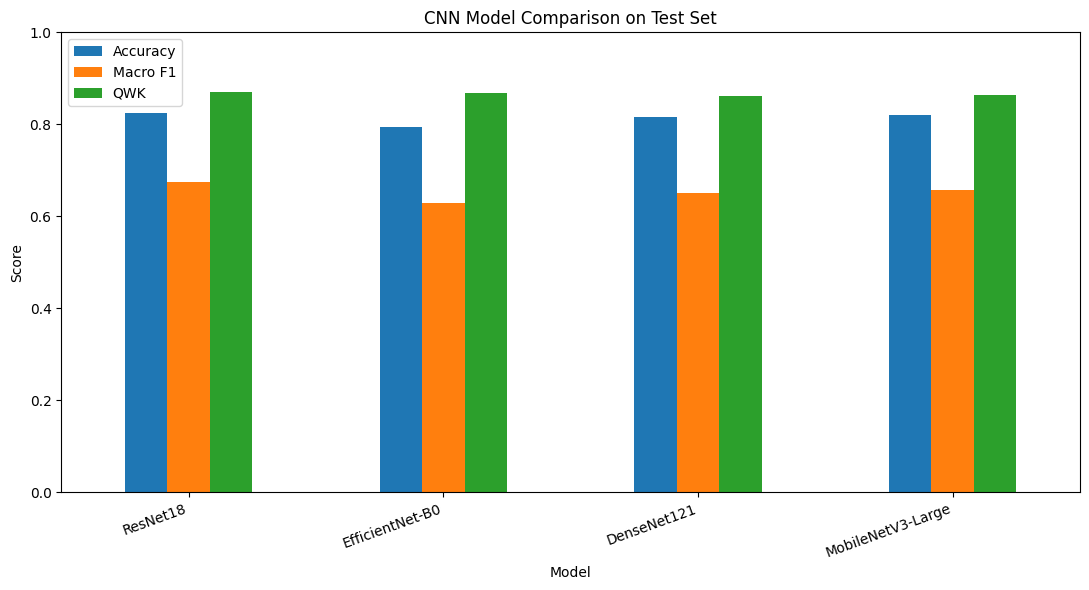


Plot saved:
/kaggle/working/DR_XAI_Project/results/model_comparison.png


STEP 16 ARTIFACT VERIFICATION
model_comparison.csv                : FOUND
model_comparison.json               : FOUND
model_comparison_report.txt         : FOUND
model_comparison.png                : FOUND
✓ ALL STEP 16 ARTIFACTS CREATED
✓ FOUR CNN TEST RESULTS COMPARED
✓ NO MODEL TRAINING PERFORMED
✓ PREVIOUS MODEL CHECKPOINTS UNCHANGED
STEP 16 COMPLETE


In [28]:
# ================================================================
# STEP 16 — CNN MODEL COMPARISON
# ================================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 16 — CNN MODEL COMPARISON")
print("=" * 70)

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

MODELS = {
    "ResNet18": "resnet18",
    "EfficientNet-B0": "efficientnet_b0",
    "DenseNet121": "densenet121",
    "MobileNetV3-Large": "mobilenet_v3_large"
}

RESULTS = {}

# ------------------------------------------------
# 1. LOAD SAVED TEST METRICS
# ------------------------------------------------

print("\n[1] LOADING SAVED TEST METRICS")
print("-" * 70)

for display_name, folder_name in MODELS.items():

    metrics_path = os.path.join(
        PROJECT_ROOT,
        "results",
        folder_name,
        "test_metrics.json"
    )

    print(f"{display_name:<22}: ", end="")

    if not os.path.exists(metrics_path):
        print("MISSING")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    RESULTS[display_name] = metrics

    print("FOUND")

print(f"\nModels loaded: {len(RESULTS)}/4")


# ------------------------------------------------
# 2. EXTRACT METRICS
# ------------------------------------------------

rows = []

for model_name, metrics in RESULTS.items():

    rows.append({
        "Model": model_name,
        "Test Loss": metrics.get("test_loss"),
        "Accuracy": metrics.get("accuracy"),
        "Macro Precision": metrics.get("macro_precision"),
        "Macro Recall": metrics.get("macro_recall"),
        "Macro F1": metrics.get("macro_f1"),
        "QWK": metrics.get("qwk")
    })

comparison_df = pd.DataFrame(rows)


# ------------------------------------------------
# 3. DISPLAY COMPARISON
# ------------------------------------------------

print("\n")
print("=" * 70)
print("CNN MODEL TEST COMPARISON")
print("=" * 70)

display(
    comparison_df.style.format({
        "Test Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "QWK": "{:.4f}"
    })
)


# ------------------------------------------------
# 4. SAVE CSV
# ------------------------------------------------

comparison_csv = os.path.join(
    PROJECT_ROOT,
    "results",
    "model_comparison.csv"
)

comparison_df.to_csv(
    comparison_csv,
    index=False
)

print("\nCSV saved:")
print(comparison_csv)


# ------------------------------------------------
# 5. SAVE JSON
# ------------------------------------------------

comparison_json = os.path.join(
    PROJECT_ROOT,
    "results",
    "model_comparison.json"
)

comparison_data = comparison_df.to_dict(
    orient="records"
)

with open(comparison_json, "w") as f:
    json.dump(
        comparison_data,
        f,
        indent=4
    )

print("\nJSON saved:")
print(comparison_json)


# ------------------------------------------------
# 6. CREATE COMPARISON REPORT
# ------------------------------------------------

report_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "model_comparison_report.txt"
)

with open(report_path, "w") as f:

    f.write("=" * 70 + "\n")
    f.write("CNN MODEL COMPARISON REPORT\n")
    f.write("=" * 70 + "\n\n")

    f.write(
        "Evaluation was performed on the untouched test set.\n"
    )

    f.write(
        "No training or parameter updates were performed during "
        "test evaluation.\n\n"
    )

    for _, row in comparison_df.iterrows():

        f.write("-" * 70 + "\n")
        f.write(f"Model: {row['Model']}\n")
        f.write(f"Test Loss       : {row['Test Loss']:.4f}\n")
        f.write(f"Accuracy        : {row['Accuracy']:.4f}\n")
        f.write(f"Macro Precision : {row['Macro Precision']:.4f}\n")
        f.write(f"Macro Recall    : {row['Macro Recall']:.4f}\n")
        f.write(f"Macro F1        : {row['Macro F1']:.4f}\n")
        f.write(f"QWK             : {row['QWK']:.4f}\n")

    f.write("\n" + "=" * 70 + "\n")

print("\nReport saved:")
print(report_path)


# ------------------------------------------------
# 7. CREATE COMPARISON PLOT
# ------------------------------------------------

plot_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "model_comparison.png"
)

metrics_to_plot = [
    "Accuracy",
    "Macro F1",
    "QWK"
]

ax = comparison_df.set_index(
    "Model"
)[metrics_to_plot].plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title(
    "CNN Model Comparison on Test Set"
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylim(
    0,
    1
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nPlot saved:")
print(plot_path)


# ------------------------------------------------
# 8. FINAL ARTIFACT VERIFICATION
# ------------------------------------------------

print("\n")
print("=" * 70)
print("STEP 16 ARTIFACT VERIFICATION")
print("=" * 70)

artifacts = [
    comparison_csv,
    comparison_json,
    report_path,
    plot_path
]

for path in artifacts:

    print(
        f"{os.path.basename(path):35} : "
        f"{'FOUND' if os.path.exists(path) else 'MISSING'}"
    )

print("=" * 70)

if all(os.path.exists(p) for p in artifacts):

    print("✓ ALL STEP 16 ARTIFACTS CREATED")
    print("✓ FOUR CNN TEST RESULTS COMPARED")
    print("✓ NO MODEL TRAINING PERFORMED")
    print("✓ PREVIOUS MODEL CHECKPOINTS UNCHANGED")

else:

    print("⚠ SOME ARTIFACTS ARE MISSING")

print("=" * 70)
print("STEP 16 COMPLETE")
print("=" * 70)

In [29]:
import inspect
import torch
import torch.nn as nn

print("=" * 70)
print("STEP 17A — IMPROVED TRAINING PIPELINE DIAGNOSTIC")
print("=" * 70)

print("\nDEVICE")
print("-" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

print("\nDATALOADERS")
print("-" * 70)
print("Train samples:", len(train_loader.dataset))
print("Validation samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))

print("\nBATCH SIZES")
print("-" * 70)
print("Train:", train_loader.batch_size)
print("Validation:", val_loader.batch_size)
print("Test:", test_loader.batch_size)

print("\nCRITERION")
print("-" * 70)
print(criterion)

print("\nTRAINING FUNCTION")
print("-" * 70)
print(inspect.signature(train_one_epoch))

print("\nVALIDATION FUNCTION")
print("-" * 70)
print(inspect.signature(validate_one_epoch))

print("\nMODEL CREATOR")
print("-" * 70)

try:
    print(inspect.signature(create_resnet18))
except Exception as e:
    print("Could not inspect create_resnet18:", e)

print("\nTRAIN DATASET")
print("-" * 70)
print(type(train_loader.dataset))

print("\nVALIDATION DATASET")
print("-" * 70)
print(type(val_loader.dataset))

print("\nTEST DATASET")
print("-" * 70)
print(type(test_loader.dataset))

print("\nTRANSFORMS")
print("-" * 70)

try:
    print("Train transform:")
    print(train_loader.dataset.transform)
except Exception as e:
    print("Train transform unavailable:", e)

try:
    print("\nValidation transform:")
    print(val_loader.dataset.transform)
except Exception as e:
    print("Validation transform unavailable:", e)

print("\nTEST TRANSFORM")
print("-" * 70)

try:
    print(test_loader.dataset.transform)
except Exception as e:
    print("Test transform unavailable:", e)

print("\n" + "=" * 70)
print("STEP 17A COMPLETE")
print("=" * 70)

STEP 17A — IMPROVED TRAINING PIPELINE DIAGNOSTIC

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

DATALOADERS
----------------------------------------------------------------------
Train samples: 2563
Validation samples: 549
Test samples: 550

BATCH SIZES
----------------------------------------------------------------------
Train: 16
Validation: 16
Test: 16

CRITERION
----------------------------------------------------------------------
CrossEntropyLoss()

TRAINING FUNCTION
----------------------------------------------------------------------
(model, loader, optimizer, criterion, device)

VALIDATION FUNCTION
----------------------------------------------------------------------
(model, loader, criterion, device)

MODEL CREATOR
----------------------------------------------------------------------
()

TRAIN DATASET
----------------------------------------------------------------------
<class '__main__.APTO

In [30]:
# ======================================================================
# STEP 17B — IMPROVED RESNET18 TRAINING
# ======================================================================

import os
import json
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import transforms

print("=" * 70)
print("STEP 17B — IMPROVED RESNET18 TRAINING")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. DEVICE
# ----------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nDEVICE")
print("-" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )


# ----------------------------------------------------------------------
# 2. NEW EXPERIMENT DIRECTORIES
# ----------------------------------------------------------------------

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"

CHECKPOINT_DIR = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "resnet18_improved"
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "resnet18_improved"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_model.pt"
)

LAST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_model.pt"
)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "training_history.csv"
)

CONFIG_PATH = os.path.join(
    RESULTS_DIR,
    "config.json"
)

print("\nEXPERIMENT STORAGE")
print("-" * 70)
print("Checkpoint directory:")
print(CHECKPOINT_DIR)

print("\nResults directory:")
print(RESULTS_DIR)


# ----------------------------------------------------------------------
# 3. PROTECT PREVIOUS EXPERIMENTS
# ----------------------------------------------------------------------

print("\nPREVIOUS MODEL SAFETY")
print("-" * 70)

previous_models = [
    "resnet18",
    "efficientnet_b0",
    "densenet121",
    "mobilenet_v3_large"
]

for model_name in previous_models:

    checkpoint_path = os.path.join(
        PROJECT_ROOT,
        "checkpoints",
        model_name,
        "best_model.pt"
    )

    metrics_path = os.path.join(
        PROJECT_ROOT,
        "results",
        model_name,
        "test_metrics.json"
    )

    print(
        f"{model_name:<20} "
        f"checkpoint={os.path.exists(checkpoint_path)} "
        f"test_metrics={os.path.exists(metrics_path)}"
    )


# ----------------------------------------------------------------------
# 4. IMPROVED TRAINING TRANSFORM
# ----------------------------------------------------------------------

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

improved_train_transform = transforms.Compose([

    transforms.Resize(
        (256, 256)
    ),

    transforms.RandomResizedCrop(
        224,
        scale=(0.85, 1.0),
        ratio=(0.95, 1.05)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ----------------------------------------------------------------------
# 5. VALIDATION TRANSFORM
# ----------------------------------------------------------------------

validation_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ----------------------------------------------------------------------
# 6. APPLY TRANSFORMS
# ----------------------------------------------------------------------

print("\nTRANSFORMS")
print("-" * 70)

print("Improved training transform:")
print(improved_train_transform)

print("\nValidation transform:")
print(validation_transform)

print("\nTest transform:")
print(test_loader.dataset.transform)


# We only modify the training dataset transform.
# Validation and test remain deterministic.

original_train_transform = train_loader.dataset.transform

train_loader.dataset.transform = improved_train_transform

# Keep validation unchanged.
# Keep test completely untouched.


# ----------------------------------------------------------------------
# 7. LOSS FUNCTION
# ----------------------------------------------------------------------

criterion_improved = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

print("\nLOSS")
print("-" * 70)
print(criterion_improved)


# ----------------------------------------------------------------------
# 8. MODEL
# ----------------------------------------------------------------------

print("\nCREATING IMPROVED RESNET18")
print("-" * 70)

model = create_resnet18()

model = model.to(device)

print("Model created")
print("Model device:", next(model.parameters()).device)


# ----------------------------------------------------------------------
# 9. OPTIMIZER
# ----------------------------------------------------------------------

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("\nOPTIMIZER")
print("-" * 70)
print("Optimizer: AdamW")
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)


# ----------------------------------------------------------------------
# 10. SCHEDULER
# ----------------------------------------------------------------------

MAX_EPOCHS = 20
PATIENCE_LIMIT = 5

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
    eta_min=1e-6
)

print("\nSCHEDULER")
print("-" * 70)
print("Scheduler: CosineAnnealingLR")
print("Minimum LR: 1e-6")


# ----------------------------------------------------------------------
# 11. TRAINING CONFIGURATION
# ----------------------------------------------------------------------

config = {

    "experiment": "resnet18_improved",

    "model": "ResNet18",

    "input_size": [224, 224],

    "max_epochs": MAX_EPOCHS,

    "early_stopping_patience": PATIENCE_LIMIT,

    "optimizer": "AdamW",

    "learning_rate": LEARNING_RATE,

    "weight_decay": WEIGHT_DECAY,

    "scheduler": "CosineAnnealingLR",

    "label_smoothing": 0.05,

    "primary_metric": "qwk",

    "test_set_used_during_training": False,

    "test_set_used_for_model_selection": False,

    "augmentation": [
        "RandomResizedCrop",
        "RandomHorizontalFlip",
        "RandomRotation",
        "ColorJitter"
    ]
}

with open(CONFIG_PATH, "w") as f:
    json.dump(
        config,
        f,
        indent=4
    )

print("\nCONFIG SAVED")
print("-" * 70)
print(CONFIG_PATH)


# ----------------------------------------------------------------------
# 12. TRAINING LOOP
# ----------------------------------------------------------------------

history = []

best_qwk = -float("inf")
best_epoch = 0
patience_counter = 0

print("\n" + "=" * 70)
print("STARTING IMPROVED RESNET18 TRAINING")
print("=" * 70)

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()

    print("\n")
    print("=" * 70)
    print(
        f"RESNET18 IMPROVED — EPOCH "
        f"{epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    # --------------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------------

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion_improved,
        device
    )

    # --------------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------------

    val_loss, val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion_improved,
        device
    )

    # --------------------------------------------------------------
    # METRICS
    # --------------------------------------------------------------

    train_qwk = train_metrics["qwk"]
    val_qwk = val_metrics["qwk"]

    current_lr = optimizer.param_groups[0]["lr"]

    print("\nTRAIN")
    print("-" * 70)
    print(f"Loss      : {train_loss:.4f}")
    print(f"Accuracy  : {train_metrics['accuracy']:.4f}")
    print(f"Macro F1  : {train_metrics['macro_f1']:.4f}")
    print(f"QWK       : {train_qwk:.4f}")

    print("\nVALIDATION")
    print("-" * 70)
    print(f"Loss      : {val_loss:.4f}")
    print(f"Accuracy  : {val_metrics['accuracy']:.4f}")
    print(f"Macro F1  : {val_metrics['macro_f1']:.4f}")
    print(f"QWK       : {val_qwk:.4f}")

    print("\nLearning rate:", f"{current_lr:.8f}")

    # --------------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------------

    history.append({

        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_qwk": train_qwk,

        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_qwk": val_qwk,

        "learning_rate": current_lr
    })

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        HISTORY_PATH,
        index=False
    )

    # --------------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------------

    if val_qwk > best_qwk:

        best_qwk = val_qwk
        best_epoch = epoch
        patience_counter = 0

        print("\n*** NEW BEST MODEL ***")
        print(
            f"Best validation QWK: "
            f"{best_qwk:.4f}"
        )

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_qwk": best_qwk,
                "config": config
            },
            BEST_PATH
        )

        print("BEST CHECKPOINT SAVED:")
        print(BEST_PATH)

    else:

        patience_counter += 1

        print("\nNo QWK improvement.")
        print(
            f"Patience: "
            f"{patience_counter}/{PATIENCE_LIMIT}"
        )

    # --------------------------------------------------------------
    # LAST CHECKPOINT
    # --------------------------------------------------------------

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch": epoch,
            "best_qwk": best_qwk,
            "patience_counter": patience_counter,
            "history": history
        },
        LAST_PATH
    )

    print("\nLAST CHECKPOINT SAVED:")
    print(LAST_PATH)

    print("\nHISTORY SAVED:")
    print(HISTORY_PATH)

    # --------------------------------------------------------------
    # SCHEDULER STEP
    # --------------------------------------------------------------

    scheduler.step()

    # --------------------------------------------------------------
    # ARTIFACT CHECK
    # --------------------------------------------------------------

    print("\nARTIFACT VERIFICATION")
    print("-" * 70)
    print("best_model.pt:", os.path.exists(BEST_PATH))
    print("last_model.pt:", os.path.exists(LAST_PATH))
    print("training_history.csv:", os.path.exists(HISTORY_PATH))
    print("config.json:", os.path.exists(CONFIG_PATH))

    epoch_time = time.time() - epoch_start

    print(
        f"\nEpoch time: "
        f"{epoch_time / 60:.2f} minutes"
    )

    # --------------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------------

    if patience_counter >= PATIENCE_LIMIT:

        print("\n" + "=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            f"No validation QWK improvement "
            f"for {PATIENCE_LIMIT} epochs."
        )

        break


# ----------------------------------------------------------------------
# 13. FINAL STATUS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("IMPROVED RESNET18 TRAINING FINISHED")
print("=" * 70)

print(
    f"Best validation QWK: "
    f"{best_qwk:.4f}"
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    "Best checkpoint exists:",
    os.path.exists(BEST_PATH)
)

print(
    "Last checkpoint exists:",
    os.path.exists(LAST_PATH)
)

print(
    "History exists:",
    os.path.exists(HISTORY_PATH)
)

print(
    "Config exists:",
    os.path.exists(CONFIG_PATH)
)


# ----------------------------------------------------------------------
# 14. FINAL ARTIFACT VERIFICATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 17B ARTIFACT VERIFICATION")
print("=" * 70)

artifacts = [
    BEST_PATH,
    LAST_PATH,
    HISTORY_PATH,
    CONFIG_PATH
]

for path in artifacts:
    print(
        f"{os.path.basename(path):30s}: "
        f"{'FOUND' if os.path.exists(path) else 'MISSING'}"
    )

print("\n" + "=" * 70)
print("STEP 17B COMPLETE")
print("=" * 70)

STEP 17B — IMPROVED RESNET18 TRAINING

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

EXPERIMENT STORAGE
----------------------------------------------------------------------
Checkpoint directory:
/kaggle/working/DR_XAI_Project/checkpoints/resnet18_improved

Results directory:
/kaggle/working/DR_XAI_Project/results/resnet18_improved

PREVIOUS MODEL SAFETY
----------------------------------------------------------------------
resnet18             checkpoint=True test_metrics=True
efficientnet_b0      checkpoint=True test_metrics=True
densenet121          checkpoint=True test_metrics=True
mobilenet_v3_large   checkpoint=True test_metrics=True

TRANSFORMS
----------------------------------------------------------------------
Improved training transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0

KeyError: 'macro_f1'

In [31]:
print("=" * 70)
print("STEP 17B-FIX — METRICS COMPATIBILITY CHECK")
print("=" * 70)

print("train_metrics type:", type(train_metrics))
print("train_metrics:", train_metrics)

if isinstance(train_metrics, dict):
    print("\nAvailable metric keys:")
    for key in train_metrics.keys():
        print(" -", key)

print("=" * 70)

STEP 17B-FIX — METRICS COMPATIBILITY CHECK
train_metrics type: <class 'dict'>
train_metrics: {'accuracy': 0.7171283651970347, 'precision': 0.5236368678394243, 'recall': 0.46552642438704417, 'f1': 0.4769376770640045, 'qwk': 0.7308086406482064}

Available metric keys:
 - accuracy
 - precision
 - recall
 - f1
 - qwk


In [32]:
# ============================================================
# FINAL PROJECT BACKUP — NO TRAINING
# ============================================================

import os
import shutil
from datetime import datetime

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"
BACKUP_DIR = "/kaggle/working/project_backup"

print("=" * 70)
print("FINAL PROJECT BACKUP")
print("=" * 70)

if not os.path.exists(PROJECT_ROOT):
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_ROOT}"
    )

# Remove old temporary backup if it exists
if os.path.exists(BACKUP_DIR):
    shutil.rmtree(BACKUP_DIR)

os.makedirs(BACKUP_DIR, exist_ok=True)

# Copy complete project
destination = os.path.join(
    BACKUP_DIR,
    "DR_XAI_Project"
)

shutil.copytree(
    PROJECT_ROOT,
    destination
)

print("\nProject copied successfully.")
print(destination)

# Create ZIP
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

zip_base = f"/kaggle/working/DR_XAI_Project_BACKUP_{timestamp}"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    BACKUP_DIR
)

print("\n" + "=" * 70)
print("BACKUP CREATED")
print("=" * 70)

print(f"\nZIP file:")
print(zip_path)

# Check size
size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print(f"Backup size: {size_mb:.2f} MB")
print("\n✓ Complete project backup created")
print("✓ No training performed")
print("✓ GPU not required")

FINAL PROJECT BACKUP

Project copied successfully.
/kaggle/working/project_backup/DR_XAI_Project

BACKUP CREATED

ZIP file:
/kaggle/working/DR_XAI_Project_BACKUP_20260930_170834.zip
Backup size: 553.99 MB

✓ Complete project backup created
✓ No training performed
✓ GPU not required


In [33]:
# ============================================================
# COMPLETE PROJECT ARTIFACT INVENTORY
# NO TRAINING
# ============================================================

import os

ROOT = "/kaggle/working/DR_XAI_Project"

print("=" * 70)
print("COMPLETE PROJECT ARTIFACT INVENTORY")
print("=" * 70)

required_files = [
    # ResNet18
    "checkpoints/resnet18/best_model.pt",
    "checkpoints/resnet18/last_model.pt",
    "results/resnet18/test_metrics.json",
    "results/resnet18/classification_report.txt",
    "results/resnet18/confusion_matrix.csv",
    "results/resnet18/confusion_matrix.png",
    "results/resnet18/test_predictions.csv",

    # EfficientNet-B0
    "checkpoints/efficientnet_b0/best_model.pt",
    "checkpoints/efficientnet_b0/last_model.pt",
    "results/efficientnet_b0/test_metrics.json",
    "results/efficientnet_b0/classification_report.txt",
    "results/efficientnet_b0/confusion_matrix.csv",
    "results/efficientnet_b0/confusion_matrix.png",
    "results/efficientnet_b0/test_predictions.csv",

    # DenseNet121
    "checkpoints/densenet121/best_model.pt",
    "checkpoints/densenet121/last_model.pt",
    "results/densenet121/test_metrics.json",
    "results/densenet121/classification_report.txt",
    "results/densenet121/confusion_matrix.csv",
    "results/densenet121/confusion_matrix.png",
    "results/densenet121/test_predictions.csv",

    # MobileNetV3
    "checkpoints/mobilenet_v3_large/best_model.pt",
    "checkpoints/mobilenet_v3_large/last_model.pt",
    "results/mobilenet_v3_large/test_metrics.json",
    "results/mobilenet_v3_large/classification_report.txt",
    "results/mobilenet_v3_large/confusion_matrix.csv",
    "results/mobilenet_v3_large/confusion_matrix.png",
    "results/mobilenet_v3_large/test_predictions.csv",

    # Comparison
    "results/model_comparison.csv",
    "results/model_comparison.json",
    "results/model_comparison_report.txt",
    "results/model_comparison.png",

    # Improved experiment
    "results/resnet18_improved/config.json",
]

found = 0
missing = 0

for rel_path in required_files:

    full_path = os.path.join(ROOT, rel_path)

    if os.path.exists(full_path):
        print(f"FOUND    : {rel_path}")
        found += 1
    else:
        print(f"MISSING  : {rel_path}")
        missing += 1

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print(f"Found   : {found}")
print(f"Missing : {missing}")

if missing == 0:
    print("\n✓ All required artifacts found.")
else:
    print("\n⚠ Some artifacts are missing.")

COMPLETE PROJECT ARTIFACT INVENTORY
FOUND    : checkpoints/resnet18/best_model.pt
FOUND    : checkpoints/resnet18/last_model.pt
FOUND    : results/resnet18/test_metrics.json
FOUND    : results/resnet18/classification_report.txt
FOUND    : results/resnet18/confusion_matrix.csv
FOUND    : results/resnet18/confusion_matrix.png
FOUND    : results/resnet18/test_predictions.csv
FOUND    : checkpoints/efficientnet_b0/best_model.pt
FOUND    : checkpoints/efficientnet_b0/last_model.pt
FOUND    : results/efficientnet_b0/test_metrics.json
FOUND    : results/efficientnet_b0/classification_report.txt
FOUND    : results/efficientnet_b0/confusion_matrix.csv
FOUND    : results/efficientnet_b0/confusion_matrix.png
FOUND    : results/efficientnet_b0/test_predictions.csv
FOUND    : checkpoints/densenet121/best_model.pt
FOUND    : checkpoints/densenet121/last_model.pt
FOUND    : results/densenet121/test_metrics.json
FOUND    : results/densenet121/classification_report.txt
FOUND    : results/densenet121/co

In [35]:
import shutil
import os

PROJECT_ROOT = "/kaggle/working/DR_XAI_Project"
ZIP_BASE = "/kaggle/working/DR_XAI_Project_backups"

# Create ZIP
zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    root_dir="/kaggle/working",
    base_dir="DR_XAI_Project"
)

print("=" * 70)
print("BACKUP ZIP CREATED")
print("=" * 70)
print(f"ZIP file: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")
print("=" * 70)

BACKUP ZIP CREATED
ZIP file: /kaggle/working/DR_XAI_Project_backups.zip
Size: 553.99 MB
